# HI 21-cm Analysis (Lab 2 Part 3): Final HI Profile Extraction

This notebook is the **third and final stage** of a three-part investigation:

1. **Part 1 (`equipment_calibration.ipynb`)**: characterize signal-chain attenuation, passband shape, and linear regime.
2. **Part 2 (`temperature_calibration.ipynb`)**: establish receiver/noise-temperature scale and export calibration contracts.
3. **Part 3 (this notebook)**: extract the HI profile with kinematic and intensity analysis, uncertainty accounting, and requirement-level traceability.

The analysis is intentionally dual-path:

- **Path A (ratio-domain)** for robust line-shape/kinematics.
- **Path B (temperature-domain)** for calibrated line intensity with hardware-aware systematics.

Final science statements are accepted only when both paths are consistent within reported uncertainties.

## Requirement Traceability Matrix (Lab Handouts → This Notebook)

| Source | Requirement / Theory Clause | Implementation in This Notebook |
|---|---|---|
| `bighorn.tex` §Analysis Week 1 | Combine spectra; compare mean vs median; smooth without erasing <1 km/s structure | Mean/median comparison + explicit smoothing-policy derivation and limit check |
| `bighorn.tex` §Analysis Week 1 | Build line-shape ratio \(s_{on}/s_{off}\) | Path A ratio-domain construction (\(R-1\), \(1/R-1\)) |
| `bighorn.tex` §Get Line Intensity | Convert to temperature scale using calibration spectra | Path B temperature mapping using `calibration_results_v2.npz` (latest contract) |
| `bighorn.tex` §Velocity + LSR | Plot in velocity and apply LSR correction | Radio Doppler axis + `ugradio.doppler.get_projected_velocity` per-spectrum correction |
| `bighorn.tex` Week 2 | Baseline removal + multi-Gaussian decomposition + fit quality | Constrained Gaussian+polynomial model grid, AICc/\(\chi_r^2\), baseline sensitivity tests |
| `cal_intensity.tex` | Naive vs cool calibration logic; product/ratio error propagation | Implemented cool-method-compatible scaling and first-order propagated uncertainties |
| `coords.tex` | Rotation-matrix coordinate chain and verification | Explicit J2000 matrix chain `(l,b)->(ra,dec)->(HA,Dec)->(Az,Alt)` + astropy/ugradio cross-check |
| `horn_signal_chain_test.tex` | Operate in linear regime; verify gain/frequency-chain sanity | Artifact-based clipping/headroom checks and linearity diagnostics before science fits |


## Implemented Theory (Handout-Aligned)

### 1) Backend radiometry model


a radiometric channel is modeled as

$$
P_j = G_j \, T_{\mathrm{sys}}(\nu_j),
$$

with

$$
T_{\mathrm{sys}}(\nu)=T_{\mathrm{rcvr}}+T_{\mathrm{ant,cont}}+T_{\mathrm{ant,HI}}(\nu)
$$

(`cal_intensity.tex`, `bighorn.tex`).

### 2) Frequency-switched ratio line-shape extraction

Using paired LO settings,

$$
R(\nu)=\frac{P_{1420}(\nu)}{P_{1421}(\nu)},\qquad y_R=R-1,
$$
$$
R^{-1}(\nu)=\frac{P_{1421}(\nu)}{P_{1420}(\nu)},\qquad y_{\mathrm{inv}}=\frac{1}{R}-1.
$$

This corresponds to the handout line-shape ratio step (bandpass division) in unitless form.

### 3) Intensity calibration and cool-method connection

Handout intensity scaling (`bighorn.tex`) is

$$
G_{\mathrm{scale}}=
\frac{T_{\mathrm{sys,cal}}-T_{\mathrm{sys,cold}}}{\sum_j (s_{\mathrm{cal},j}-s_{\mathrm{cold},j})}
\sum_j s_{\mathrm{cold},j},
$$

with calibrated line estimate

$$
T_{\mathrm{line}} = r_{\mathrm{line}}\, G_{\mathrm{scale}}.
$$

`cal_intensity.tex` shows the lower-noise cool-method decomposition: ratio gives **shape**, channel-averaged calibration gives **scale**. In this notebook, that appears as

$$
T_{\mathrm{sys,ref}}(\nu)=P_{\mathrm{ref}}(\nu)
\frac{T_{\mathrm{cold}}+T_{\mathrm{rx}}}{P_{\mathrm{cold,ref}}(\nu)},
$$
$$
T_{\mathrm{line},R}=(R-1)\,T_{\mathrm{sys,ref}},
$$
$$
T_{\mathrm{line},\mathrm{inv}}=-\frac{y_{\mathrm{inv}}}{1+y_{\mathrm{inv}}}\,T_{\mathrm{sys,ref}}.
$$

### 4) Velocity axis and LSR frame

Radio velocity convention:

$$
v_{\mathrm{radio}} = c\,\frac{\nu_0-\nu}{\nu_0}.
$$

Frame correction:

$$
v_{\mathrm{LSR}} = v_{\mathrm{topo}} + \Delta v_{\mathrm{LSR}},
$$

where \(\Delta v_{\mathrm{LSR}}\) is computed with `ugradio.doppler.get_projected_velocity` from observation time, site, and pointing metadata.

### 5) Baseline + Gaussian decomposition model

$$
y(v)=\sum_{k=1}^{N} A_k\exp\!\left[-\frac{(v-\mu_k)^2}{2\sigma_k^2}\right] + \sum_{m=0}^{M} c_m (v/100)^m.
$$

Off-line channels are used only to seed the polynomial coefficients; the final optimizer re-fits the Gaussian components and baseline simultaneously over the full fit window.
Model grid search reports \(\chi_r^2\), AICc, and physical-width compliance; baseline-order perturbations compare alternate joint Gaussian+baseline fits to estimate a baseline-model systematic term.

### 6) Uncertainty propagation

Product/ratio propagation follows first-order Taylor form (`cal_intensity.tex`):

$$
\left(\frac{\sigma_q}{q}\right)^2 = \sum_i \left(\frac{\partial \ln q}{\partial x_i}\sigma_{x_i}\right)^2,
$$

with terms for ratio statistics, temperature-calibration uncertainty, and hardware systematic fraction.

## Step 1 - Setup constants, policies, and file contracts

- Enforce calibration-contract ingestion from Parts 1 and 2.
- Keep Path A and Path B parity.
- Use a fixed smoothing policy constrained by the 1 km/s handout requirement.
- Use deterministic constrained model selection with reproducible caches.

In [19]:
from dataclasses import dataclass
from pathlib import Path

import csv
import pickle as _pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import scipy.signal as sig
import ugradio.doppler
import astropy.coordinates as astro_coord
import astropy.time as astro_time
import astropy.units as astro_u

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['figure.dpi'] = 300

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')
NB_DIR = Path('labs/02') if Path('labs/02').exists() else Path('.')
CACHE_DIR = NB_DIR / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CAL_CANDIDATES = [
    CACHE_DIR / 'calibration_results_v2.npz',
    NB_DIR / 'calibration_results_v2.npz',
    Path('calibration_results_v2.npz'),
    Path('../calibration_results_v2.npz'),
]
CAL_PATH = next((p for p in CAL_CANDIDATES if p.exists()), None)
if CAL_PATH is None:
    candidate_list = ', '.join(str(p) for p in CAL_CANDIDATES)
    raise FileNotFoundError(
        'Missing calibration artifact. Ensure one of this list exists: ' + candidate_list
    )
EQ_CANDIDATES = [
    CACHE_DIR / 'equipment_calibration_results_v2.npz',
    NB_DIR / 'equipment_calibration_results_v2.npz',
    Path('equipment_calibration_results_v2.npz'),
    Path('../equipment_calibration_results_v2.npz'),
]
EQ_PATH = next((p for p in EQ_CANDIDATES if p.exists()), None)
if EQ_PATH is None:
    candidate_list = ', '.join(str(p) for p in EQ_CANDIDATES)
    raise FileNotFoundError('Missing equipment artifact. Ensure one of: ' + candidate_list)
ETA_PATHS = [
    Path('labs/02/report/eta_eff_estimate.csv'),
    Path('report/eta_eff_estimate.csv'),
    Path('../report/eta_eff_estimate.csv'),
]

HI_REST_FREQ_HZ = 1_420_405_751.768
C_LIGHT_KMS = 2.99792458e5

RFI_SIGMA = 5.0
SAVGOL = dict(method='savgol', window_length=257, polyorder=3)
ROLLING_W = 200

# Handout-constrained smoothing policy: keep effective smoothing <= 1 km/s.
SMOOTH_METHOD = 'mean'
SMOOTH_NCHAN = 31
MAX_SMOOTH_KMS = 1.0

# Offline baseline windows from bighorn.tex guidance: 0.6-1.2 MHz off line center.
OFFLINE_MIN_MHZ = 0.6
OFFLINE_MAX_MHZ = 1.2
OFFLINE_MIN_KMS = C_LIGHT_KMS * (OFFLINE_MIN_MHZ * 1e6) / HI_REST_FREQ_HZ
OFFLINE_MAX_KMS = C_LIGHT_KMS * (OFFLINE_MAX_MHZ * 1e6) / HI_REST_FREQ_HZ

FIT_WINDOWS_KMS = {
    'standard': (-135.0, 20.0),
    'cygnus-x': (-135.0, 30.0),
}

N_GAUSS_GRID = (2, 3, 4)
POLY_GRID = (1, 2)
# Seed-width heuristics only; the final optimizer uses SIGMA_PHYS_* hard bounds.
NAIVE_SIG_MIN_KMS = 0.85
NAIVE_SIG_MAX_KMS = 21.2
FWHM_PHYS_MIN_KMS = 3.0
FWHM_PHYS_MAX_KMS = 35.0
SIGMA_PHYS_MIN_KMS = FWHM_PHYS_MIN_KMS / 2.355
SIGMA_PHYS_MAX_KMS = FWHM_PHYS_MAX_KMS / 2.355
PHYSICS_WIDTH_EDGE_MARGIN_FRAC = 0.05
PHYSICS_WIDTH_PENALTY_LAMBDA = 3.0
NAIVE_MULTI_STARTS = 4
FIT_SEED = 42
FIT_CACHE_SIGNATURE = (
    f'fitv8_jointphys_lomask_ng{N_GAUSS_GRID}_pg{POLY_GRID}_'
    f'sig{SIGMA_PHYS_MIN_KMS:.3f}-{SIGMA_PHYS_MAX_KMS:.3f}_'
    f'margin{PHYSICS_WIDTH_EDGE_MARGIN_FRAC:.3f}_'
    f'lam{PHYSICS_WIDTH_PENALTY_LAMBDA:.2f}_'
    f'sm{SMOOTH_METHOD}{SMOOTH_NCHAN}'
)

# Set True to ignore cached fits and recompute from scratch.
FORCE_REFIT = False

_CACHE_DIR = CACHE_DIR
_CACHE_A   = _CACHE_DIR / 'analysis_cache_path_a.pkl'
_CACHE_B   = _CACHE_DIR / 'analysis_cache_path_b.pkl'
_CACHE_SYS = _CACHE_DIR / 'analysis_cache_baseline_sys.pkl'

print(f'DATA_ROOT: {DATA_ROOT.resolve()}')
print(f'CAL_PATH : {CAL_PATH} (using {CAL_PATH.name})')
print(f'EQ_PATH  : {EQ_PATH}')
print(f'FORCE_REFIT: {FORCE_REFIT}')
print(f'Smoothing policy: method={SMOOTH_METHOD}, nchan={SMOOTH_NCHAN}, max_width={MAX_SMOOTH_KMS:.2f} km/s')
print(f'Offline guidance windows: {OFFLINE_MIN_MHZ:.1f}-{OFFLINE_MAX_MHZ:.1f} MHz ({OFFLINE_MIN_KMS:.1f}-{OFFLINE_MAX_KMS:.1f} km/s)')


DATA_ROOT: /Users/junruiting/GitHub/ay-121/data/lab02
CAL_PATH : cache/calibration_results_v2.npz (using calibration_results_v2.npz)
EQ_PATH  : cache/equipment_calibration_results_v2.npz
FORCE_REFIT: False
Smoothing policy: method=mean, nchan=31, max_width=1.00 km/s
Offline guidance windows: 0.6-1.2 MHz (126.6-253.3 km/s)


## Step 2 - Helper operators (I/O, interpolation, masking, smoothing, fitting)

In [20]:

def _available_keys(npz_obj):
    if hasattr(npz_obj, 'files'):
        return list(npz_obj.files)
    return list(npz_obj.keys())


def require_keys(npz_obj, required_keys, label: str):
    available = _available_keys(npz_obj)
    missing = [k for k in required_keys if k not in available]
    if missing:
        raise KeyError(f'{label}: missing required keys {missing}')


def load_lo_pair(spectra_dir: Path) -> dict:
    spectra_dir = Path(spectra_dir)
    pairs = {}
    for f in sorted(spectra_dir.glob('*.npz')):
        spec = Spectrum.load(f)
        lo_mhz = int(round(spec.center_freq / 1e6))
        pairs[lo_mhz] = spec
    if 1420 not in pairs or 1421 not in pairs:
        raise ValueError(f'Expected LO 1420 and 1421 in {spectra_dir}, got {list(pairs.keys())}')
    return pairs


def lo_center_bin_index(spectrum: Spectrum) -> int:
    return int(spectrum.bin_at(float(spectrum.center_freq)))


def lo_analysis_mask(spectrum: Spectrum) -> np.ndarray:
    mask = np.ones(np.asarray(spectrum.psd).shape, dtype=bool)
    idx_center = lo_center_bin_index(spectrum)
    if 0 <= idx_center < mask.size:
        mask[idx_center] = False
    if not np.any(mask):
        raise ValueError('Spectrum has no channels left after removing the LO center bin.')
    return mask


def combine_spectrum_mask(spectrum: Spectrum,
                          *masks: np.ndarray,
                          require_nonempty: bool = False) -> np.ndarray:
    combined = lo_analysis_mask(spectrum)
    for mask in masks:
        if mask is None:
            continue
        arr = np.asarray(mask, bool)
        if arr.shape != combined.shape:
            raise ValueError(f'Mask shape {arr.shape} does not match spectrum shape {combined.shape}.')
        combined &= arr
    if require_nonempty and not np.any(combined):
        raise ValueError('No analysis channels remain after masking the LO center bin.')
    return combined


def masked_spectrum_values(spectrum: Spectrum,
                           values: np.ndarray | None = None,
                           mask: np.ndarray | None = None,
                           fill_value=np.nan) -> np.ndarray:
    base = spectrum.psd_values(mask_dc=True) if values is None else spectrum.mask_dc_bin(values)
    arr = np.array(base, dtype=float, copy=True)
    combined = combine_spectrum_mask(spectrum, mask)
    arr[~combined] = fill_value
    return arr


def fill_masked_spectrum_values(spectrum: Spectrum,
                                values: np.ndarray | None = None,
                                mask: np.ndarray | None = None) -> np.ndarray:
    arr = masked_spectrum_values(spectrum, values=values, mask=mask)
    finite = np.isfinite(arr)
    if finite.sum() < 2:
        raise ValueError('Need at least two finite channels to interpolate across the LO bin.')
    idx = np.arange(arr.size, dtype=float)
    filled = arr.copy()
    filled[~finite] = np.interp(idx[~finite], idx[finite], arr[finite])
    return filled


def smooth_series(values: np.ndarray, smooth_kwargs: dict) -> np.ndarray:
    arr = np.asarray(values, float)
    method = smooth_kwargs.get('method', 'savgol')

    if method == 'savgol':
        window_length = int(smooth_kwargs.get('window_length', 129))
        if window_length % 2 == 0:
            window_length += 1
        if window_length >= arr.size:
            window_length = arr.size - 1 if arr.size % 2 == 0 else arr.size
        if window_length < 3:
            return arr.copy()
        polyorder = min(int(smooth_kwargs.get('polyorder', 3)), window_length - 1)
        return sig.savgol_filter(arr, window_length=window_length, polyorder=polyorder, mode='interp')

    if method == 'boxcar':
        width = int(smooth_kwargs.get('M', 64))
        if width <= 1:
            return arr.copy()
        kernel = np.ones(width, float) / width
        return np.convolve(arr, kernel, mode='same')

    if method == 'gaussian':
        from scipy.ndimage import gaussian_filter1d
        return gaussian_filter1d(arr, sigma=float(smooth_kwargs.get('sigma', 32)))

    raise ValueError(f'Unsupported smoothing method for LO-masked series: {method!r}')


def sigma_clip_rfi_mask(spectrum: Spectrum,
                        n_sigma: float = RFI_SIGMA,
                        smooth_kwargs: dict = SAVGOL) -> np.ndarray:
    psd = masked_spectrum_values(spectrum)
    baseline_seed = fill_masked_spectrum_values(spectrum)
    baseline = masked_spectrum_values(spectrum, smooth_series(baseline_seed, smooth_kwargs))
    resid = psd - baseline
    n = len(resid)
    half = ROLLING_W // 2
    local_std = np.full(n, np.nan, dtype=float)
    for i in range(n):
        window = resid[max(0, i - half):min(n, i + half + 1)]
        finite = np.isfinite(window)
        if np.any(finite):
            local_std[i] = np.nanstd(window[finite])
    good = np.isfinite(resid) & np.isfinite(local_std)
    good &= np.abs(resid) <= n_sigma * np.maximum(local_std, 1e-12)
    return combine_spectrum_mask(spectrum, good)


def velocity_axis(freqs_hz: np.ndarray,
                  rest_freq_hz: float = HI_REST_FREQ_HZ) -> np.ndarray:
    return C_LIGHT_KMS * (rest_freq_hz - freqs_hz) / rest_freq_hz


def lsr_correction_kms(spectrum: Spectrum) -> float:
    # Preferred path: use recorded telescope pointing (Az/Alt) and observation JD.
    ra_deg = np.nan
    dec_deg = np.nan

    has_altaz = hasattr(spectrum, 'az') and hasattr(spectrum, 'alt')
    if has_altaz:
        az_deg = float(getattr(spectrum, 'az'))
        alt_deg = float(getattr(spectrum, 'alt'))
        if np.isfinite(az_deg) and np.isfinite(alt_deg):
            location = astro_coord.EarthLocation(
                lat=float(spectrum.obs_lat) * astro_u.deg,
                lon=float(spectrum.obs_lon) * astro_u.deg,
                height=float(spectrum.obs_alt) * astro_u.m,
            )
            obstime = astro_time.Time(float(spectrum.jd), format='jd')
            frame_altaz = astro_coord.AltAz(obstime=obstime, location=location)
            sky_altaz = astro_coord.SkyCoord(
                az=az_deg * astro_u.deg,
                alt=alt_deg * astro_u.deg,
                frame=frame_altaz,
            )
            sky_icrs = sky_altaz.icrs
            ra_deg = float(sky_icrs.ra.deg)
            dec_deg = float(sky_icrs.dec.deg)

    # Fallback used only if Az/Alt metadata are unavailable.
    if not (np.isfinite(ra_deg) and np.isfinite(dec_deg)):
        ra_deg = float(np.degrees(float(spectrum.lst)))
        dec_deg = float(spectrum.obs_lat)

    v_ms = ugradio.doppler.get_projected_velocity(
        ra=ra_deg,
        dec=dec_deg,
        jd=spectrum.jd,
        obs_lat=spectrum.obs_lat,
        obs_lon=spectrum.obs_lon,
        obs_alt=spectrum.obs_alt,
    )
    return float(v_ms / 1e3)


def interp_mono(x_src: np.ndarray,
                y_src: np.ndarray,
                x_new: np.ndarray,
                fill_value=np.nan) -> np.ndarray:
    x_src = np.asarray(x_src, dtype=float)
    y_src = np.asarray(y_src, dtype=float)
    x_new = np.asarray(x_new, dtype=float)

    finite = np.isfinite(x_src) & np.isfinite(y_src)
    if finite.sum() < 2:
        return np.full_like(x_new, fill_value, dtype=float)

    xs = x_src[finite]
    ys = y_src[finite]
    order = np.argsort(xs)
    xs = xs[order]
    ys = ys[order]

    out = np.interp(x_new, xs, ys)
    out[(x_new < xs[0]) | (x_new > xs[-1])] = fill_value
    return out


def interp_bool_nearest(x_src: np.ndarray,
                        mask_src: np.ndarray,
                        x_new: np.ndarray,
                        default=False) -> np.ndarray:
    x_src = np.asarray(x_src, float)
    mask_src = np.asarray(mask_src, bool)
    x_new = np.asarray(x_new, float)

    finite = np.isfinite(x_src)
    if finite.sum() < 2:
        return np.full_like(x_new, bool(default), dtype=bool)

    xs = x_src[finite]
    ms = mask_src[finite]
    order = np.argsort(xs)
    xs = xs[order]
    ms = ms[order]

    idx = np.searchsorted(xs, x_new)
    idx = np.clip(idx, 1, len(xs) - 1)
    left = xs[idx - 1]
    right = xs[idx]
    pick_right = np.abs(x_new - right) < np.abs(x_new - left)
    nearest_idx = np.where(pick_right, idx, idx - 1)
    out = ms[nearest_idx]
    out[(x_new < xs[0]) | (x_new > xs[-1])] = bool(default)
    return out


def robust_mad_sigma(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return float(1.4826 * mad + 1e-12)


def smooth_nanboxcar(y: np.ndarray, nchan: int) -> np.ndarray:
    y = np.asarray(y, float)
    if nchan <= 1:
        return y.copy()
    if nchan % 2 == 0:
        nchan += 1
    good = np.isfinite(y).astype(float)
    y0 = np.where(np.isfinite(y), y, 0.0)
    k = np.ones(nchan, float)
    num = np.convolve(y0, k, mode='same')
    den = np.convolve(good, k, mode='same')
    out = np.full_like(y, np.nan, dtype=float)
    ok = den > 0
    out[ok] = num[ok] / den[ok]
    return out


def smooth_nanmedian(y: np.ndarray, nchan: int) -> np.ndarray:
    y = np.asarray(y, float)
    if nchan <= 1:
        return y.copy()
    if nchan % 2 == 0:
        nchan += 1
    half = nchan // 2
    out = np.full_like(y, np.nan, dtype=float)
    for i in range(y.size):
        seg = y[max(0, i - half):min(y.size, i + half + 1)]
        seg = seg[np.isfinite(seg)]
        if seg.size:
            out[i] = np.nanmedian(seg)
    return out


def smooth_profile_with_sigma(y: np.ndarray,
                              sigma: np.ndarray,
                              nchan: int,
                              method: str = 'mean'):
    y = np.asarray(y, float)
    sigma = np.asarray(sigma, float)
    if nchan <= 1:
        return y.copy(), sigma.copy()

    if method != 'mean':
        raise ValueError(f"Only mean smoothing is supported in the production path; got {method!r}")

    y_sm = smooth_nanboxcar(y, nchan)

    var = np.where(np.isfinite(sigma), sigma ** 2, np.nan)
    var_sm = smooth_nanboxcar(var, nchan)
    # Mean smoothing: variance scales as 1/N^2 sum(sigma_i^2).
    sig_sm = np.sqrt(np.clip(var_sm / max(nchan, 1), 0.0, np.inf))
    return y_sm, sig_sm


def _cache_has_ok_rows(model_tables: dict) -> bool:
    if not isinstance(model_tables, dict) or len(model_tables) == 0:
        return False
    for t in model_tables.values():
        if 'status' not in t:
            return False
        status = np.asarray(t['status']).astype(str)
        if not np.any(status == 'ok'):
            return False
    return True


def _eval_poly(v: np.ndarray, coeffs: np.ndarray) -> np.ndarray:
    x = np.asarray(v, float) / 100.0
    out = np.zeros_like(x)
    for j, c in enumerate(np.asarray(coeffs, float)):
        out += c * x**j
    return out


@dataclass(frozen=True)
class FitResult:
    n_gauss: int
    poly_order: int
    popt: np.ndarray
    perr: np.ndarray
    chi2: float
    dof: int
    chi2_red: float
    vel_fit: np.ndarray
    data_fit: np.ndarray
    sigma_fit: np.ndarray

    def model(self, vel: np.ndarray) -> np.ndarray:
        return gauss_poly_model(vel, self.popt, self.n_gauss, self.poly_order)


def gauss_poly_model(vel: np.ndarray,
                     params: np.ndarray,
                     n_gauss: int,
                     poly_order: int) -> np.ndarray:
    vel = np.asarray(vel, float)
    params = np.asarray(params, float)
    out = np.zeros_like(vel)
    for k in range(n_gauss):
        A = params[3*k]
        mu = params[3*k+1]
        sig_k = max(params[3*k+2], 1e-6)
        out += A * np.exp(-0.5 * ((vel - mu) / sig_k) ** 2)
    out += _eval_poly(vel, params[3*n_gauss:3*n_gauss + poly_order + 1])
    return out


def fit_weighted_baseline_seed(v: np.ndarray,
                               y: np.ndarray,
                               s: np.ndarray,
                               poly_order: int,
                               outer_kms: float = OFFLINE_MIN_KMS) -> np.ndarray:
    """Seed the polynomial baseline from offline channels; final fits re-optimize it jointly."""
    use_outer = np.abs(v) > outer_kms
    if use_outer.sum() <= poly_order:
        use_outer = np.ones_like(v, dtype=bool)
    coeff_high_to_low = np.polyfit(
        v[use_outer] / 100.0,
        y[use_outer],
        deg=poly_order,
        w=1.0 / np.maximum(s[use_outer], 1e-9),
    )
    return coeff_high_to_low[::-1]


def find_gaussian_seeds(v: np.ndarray,
                        y_line: np.ndarray,
                        n_gauss: int,
                        vel_min: float,
                        vel_max: float):
    finite = np.isfinite(v) & np.isfinite(y_line) & (v >= vel_min) & (v <= vel_max)
    v_use = np.asarray(v[finite], float)
    y_use = np.asarray(y_line[finite], float)
    if v_use.size < max(8, n_gauss):
        raise ValueError('Insufficient channels for seed finding.')

    order = np.argsort(v_use)
    v_use = v_use[order]
    y_use = y_use[order]

    n = v_use.size
    win = max(7, min(61, (n // 6) * 2 + 1))
    if win >= n:
        win = n - 1 if n % 2 == 0 else n
    if win % 2 == 0:
        win -= 1
    if win < 5:
        win = 5 if n >= 5 else max(3, n | 1)

    if 5 <= win < n:
        y_smooth = sig.savgol_filter(y_use, window_length=win, polyorder=2, mode='interp')
    else:
        y_smooth = y_use.copy()

    resid_scale = robust_mad_sigma(y_use - y_smooth)
    y_scale = max(float(np.nanmax(np.abs(y_smooth))), resid_scale, 1e-6)

    dv = np.nanmedian(np.diff(v_use))
    dv = float(abs(dv)) if np.isfinite(dv) and dv != 0 else 1.0
    min_dist = max(2, int(round(12.0 / dv)))

    peaks, props = sig.find_peaks(
        y_smooth,
        prominence=max(2.0 * resid_scale, 0.05 * y_scale),
        distance=min_dist,
    )

    amps, mus, sigmas = [], [], []
    if peaks.size > 0:
        ord2 = np.argsort(props['prominences'])[::-1]
        peaks = peaks[ord2]
        widths, _, _, _ = sig.peak_widths(y_smooth, peaks, rel_height=0.5)
        for pidx, width in zip(peaks, widths):
            if len(amps) >= n_gauss:
                break
            amp = float(max(y_smooth[pidx], 0.01 * y_scale))
            mu = float(v_use[pidx])
            sigma_k = float(np.clip((width * dv) / 2.355, NAIVE_SIG_MIN_KMS, NAIVE_SIG_MAX_KMS))
            amps.append(amp)
            mus.append(mu)
            sigmas.append(sigma_k)

    if len(amps) < n_gauss:
        fallback_mu = np.linspace(vel_min + 0.2*(vel_max-vel_min), vel_max - 0.2*(vel_max-vel_min), n_gauss)
        base_amp = max(np.percentile(np.maximum(y_use, 0.0), 90), 0.02*y_scale, 1e-4)
        while len(amps) < n_gauss:
            k = len(amps)
            amps.append(float(base_amp * (0.9 ** k)))
            mus.append(float(fallback_mu[k]))
            sigmas.append(float(0.5 * (SIGMA_PHYS_MIN_KMS + SIGMA_PHYS_MAX_KMS)))

    A0 = np.asarray(amps[:n_gauss], float)
    mu0 = np.asarray(mus[:n_gauss], float)
    sig0 = np.asarray(sigmas[:n_gauss], float)
    ord3 = np.argsort(mu0)
    return A0[ord3], mu0[ord3], sig0[ord3]


def _reorder_component_params(params: np.ndarray,
                              errors: np.ndarray,
                              n_gauss: int,
                              poly_order: int):
    mu = np.array([params[3*k+1] for k in range(n_gauss)])
    order = np.argsort(mu)
    p2 = params.copy()
    e2 = errors.copy()
    for out_k, src_k in enumerate(order):
        p2[3*out_k:3*out_k+3] = params[3*src_k:3*src_k+3]
        e2[3*out_k:3*out_k+3] = errors[3*src_k:3*src_k+3]
    p2[3*n_gauss:3*n_gauss+poly_order+1] = params[3*n_gauss:3*n_gauss+poly_order+1]
    e2[3*n_gauss:3*n_gauss+poly_order+1] = errors[3*n_gauss:3*n_gauss+poly_order+1]
    return p2, e2



def _physics_width_penalty_terms(theta: np.ndarray,
                                 n_gauss: int) -> np.ndarray:
    sigmas = np.array([theta[3*k+2] for k in range(n_gauss)], dtype=float)
    if sigmas.size == 0:
        return np.array([], dtype=float)

    scale = max(SIGMA_PHYS_MAX_KMS - SIGMA_PHYS_MIN_KMS, 1e-6)
    edge_margin = max(PHYSICS_WIDTH_EDGE_MARGIN_FRAC * scale, 1e-6)
    lower_soft = SIGMA_PHYS_MIN_KMS + edge_margin
    upper_soft = SIGMA_PHYS_MAX_KMS - edge_margin
    near_low = np.clip(lower_soft - sigmas, 0.0, np.inf)
    near_high = np.clip(sigmas - upper_soft, 0.0, np.inf)
    return np.concatenate([near_low / edge_margin, near_high / edge_margin])


def _fit_n_phys_viol(params: np.ndarray,
                     n_gauss: int) -> int:
    sigmas = np.array([params[3*k+2] for k in range(n_gauss)], dtype=float)
    bad = (~np.isfinite(sigmas)) | (sigmas < SIGMA_PHYS_MIN_KMS) | (sigmas > SIGMA_PHYS_MAX_KMS)
    return int(np.sum(bad))

def gauss_poly_fit(vel: np.ndarray,
                   profile: np.ndarray,
                   sigma: np.ndarray,
                   n_gauss: int,
                   poly_order: int,
                   vel_min: float,
                   vel_max: float,
                   n_multistart: int = NAIVE_MULTI_STARTS,
                   random_seed: int = FIT_SEED) -> FitResult:
    mask = (np.isfinite(vel) & np.isfinite(profile) & np.isfinite(sigma)
            & (sigma > 0) & (vel >= vel_min) & (vel <= vel_max))
    v = np.asarray(vel[mask], float)
    y = np.asarray(profile[mask], float)
    s = np.asarray(sigma[mask], float)

    k_params = 3*n_gauss + poly_order + 1
    if v.size <= k_params + 2:
        raise ValueError('Insufficient channels for fit complexity.')

    ordv = np.argsort(v)
    v, y, s = v[ordv], y[ordv], s[ordv]

    baseline_seed = fit_weighted_baseline_seed(v, y, s, poly_order=poly_order)
    baseline_seed_eval = _eval_poly(v, baseline_seed)
    A0, mu0, sig0 = find_gaussian_seeds(v, y - baseline_seed_eval, n_gauss, vel_min, vel_max)
    sig0 = np.clip(sig0, SIGMA_PHYS_MIN_KMS, SIGMA_PHYS_MAX_KMS)

    p0 = np.concatenate([np.column_stack([A0, mu0, sig0]).ravel(), baseline_seed])

    lb = np.array([0.0, vel_min, SIGMA_PHYS_MIN_KMS] * n_gauss + [-np.inf]*(poly_order+1), dtype=float)
    ub = np.array([np.inf, vel_max, SIGMA_PHYS_MAX_KMS] * n_gauss + [np.inf]*(poly_order+1), dtype=float)

    def resid(theta: np.ndarray) -> np.ndarray:
        data_resid = (y - gauss_poly_model(v, theta, n_gauss, poly_order)) / s
        if PHYSICS_WIDTH_PENALTY_LAMBDA <= 0:
            return data_resid

        width_pen = _physics_width_penalty_terms(theta, n_gauss)
        if width_pen.size == 0:
            return data_resid

        return np.concatenate([data_resid, np.sqrt(PHYSICS_WIDTH_PENALTY_LAMBDA) * width_pen])

    rng = np.random.default_rng(random_seed)
    starts = [p0]
    for _ in range(n_multistart):
        trial = p0.copy()
        for k in range(n_gauss):
            trial[3*k] *= np.exp(rng.normal(0.0, 0.25))
            trial[3*k+1] += rng.normal(0.0, 8.0)
            trial[3*k+2] *= np.exp(rng.normal(0.0, 0.20))
        trial[3*n_gauss:3*n_gauss+poly_order+1] += rng.normal(0.0, 0.2*robust_mad_sigma(y), size=poly_order+1)
        trial = np.clip(trial, lb + 1e-9, ub - 1e-9)
        starts.append(trial)

    best = None
    best_cost = np.inf
    for start in starts:
        try:
            res = opt.least_squares(
                resid,
                start,
                bounds=(lb, ub),
                loss='soft_l1',
                f_scale=1.0,
                max_nfev=60000,
            )
        except Exception:
            continue
        # Accept any run that didn't throw — res.success is often False even for
        # good fits (gtol/ftol not tight enough), so we use cost as the criterion.
        if res.cost < best_cost:
            best = res
            best_cost = float(res.cost)

    if best is None:
        raise RuntimeError('All least-squares starts failed.')

    popt = np.asarray(best.x, float)
    r_data = (y - gauss_poly_model(v, popt, n_gauss, poly_order)) / s
    dof = max(v.size - popt.size, 1)
    chi2 = float(np.sum(r_data**2))
    chi2_red = chi2 / dof

    try:
        jtj_inv = np.linalg.inv(best.jac.T @ best.jac)
        pcov = jtj_inv * chi2_red
        perr = np.sqrt(np.clip(np.diag(pcov), 0, np.inf))
    except np.linalg.LinAlgError:
        perr = np.full_like(popt, np.nan)

    popt, perr = _reorder_component_params(popt, perr, n_gauss, poly_order)
    return FitResult(n_gauss, poly_order, popt, perr, chi2, dof, chi2_red, v, y, s)


def _fallback_fit_result(vel: np.ndarray,
                         profile: np.ndarray,
                         sigma: np.ndarray,
                         vel_min: float,
                         vel_max: float) -> FitResult:
    """Construct a conservative 1-Gaussian + constant-baseline joint fit when grid fits fail."""
    try:
        return gauss_poly_fit(
            vel,
            profile,
            sigma,
            n_gauss=1,
            poly_order=0,
            vel_min=vel_min,
            vel_max=vel_max,
            n_multistart=max(2, NAIVE_MULTI_STARTS),
            random_seed=FIT_SEED + 101,
        )
    except Exception:
        pass

    mask = (np.isfinite(vel) & np.isfinite(profile) & np.isfinite(sigma)
            & (sigma > 0) & (vel >= vel_min) & (vel <= vel_max))
    v = np.asarray(vel[mask], float)
    y = np.asarray(profile[mask], float)
    s = np.asarray(sigma[mask], float)

    if v.size < 8:
        raise RuntimeError('Fallback fit failed: insufficient finite channels in fit window.')

    order = np.argsort(v)
    v, y, s = v[order], y[order], s[order]

    outer = np.abs(v) > 80.0
    if outer.sum() < 5:
        outer = np.ones_like(v, dtype=bool)
    baseline_seed = float(np.nanmedian(y[outer]))
    y_line = y - baseline_seed

    w = np.clip(y_line, 0.0, np.inf)
    if np.nansum(w) <= 0:
        w = np.abs(y_line)
    if np.nansum(w) <= 0:
        w = np.ones_like(v, float)

    mu = float(np.nansum(w * v) / np.nansum(w))
    var = float(np.nansum(w * (v - mu) ** 2) / np.nansum(w))
    sigma_k = float(np.clip(np.sqrt(max(var, 1e-12)), SIGMA_PHYS_MIN_KMS, SIGMA_PHYS_MAX_KMS))

    amp_candidates = y_line[np.isfinite(y_line)]
    if amp_candidates.size:
        amp = float(np.nanmax(amp_candidates))
    else:
        amp = 0.0
    if not np.isfinite(amp) or amp <= 0:
        amp = float(max(np.nanmax(np.abs(y_line)) if y_line.size else 0.0, 1e-6))

    p0 = np.array([amp, mu, sigma_k, baseline_seed], dtype=float)
    lb = np.array([0.0, vel_min, SIGMA_PHYS_MIN_KMS, -np.inf], dtype=float)
    ub = np.array([np.inf, vel_max, SIGMA_PHYS_MAX_KMS, np.inf], dtype=float)
    p0 = np.clip(p0, lb + 1e-9, ub - 1e-9)

    def resid(theta: np.ndarray) -> np.ndarray:
        data_resid = (y - gauss_poly_model(v, theta, n_gauss=1, poly_order=0)) / s
        if PHYSICS_WIDTH_PENALTY_LAMBDA <= 0:
            return data_resid
        width_pen = _physics_width_penalty_terms(theta, 1)
        if width_pen.size == 0:
            return data_resid
        return np.concatenate([data_resid, np.sqrt(PHYSICS_WIDTH_PENALTY_LAMBDA) * width_pen])

    try:
        best = opt.least_squares(
            resid,
            p0,
            bounds=(lb, ub),
            loss='soft_l1',
            f_scale=1.0,
            max_nfev=20000,
        )
        popt = np.asarray(best.x, float)
    except Exception:
        best = None
        popt = p0

    model = gauss_poly_model(v, popt, n_gauss=1, poly_order=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        r = (y - model) / s
    chi2 = float(np.nansum(r ** 2))
    dof = max(v.size - popt.size, 1)
    chi2_red = chi2 / dof

    if best is not None:
        try:
            jtj_inv = np.linalg.inv(best.jac.T @ best.jac)
            pcov = jtj_inv * chi2_red
            perr = np.sqrt(np.clip(np.diag(pcov), 0, np.inf))
        except np.linalg.LinAlgError:
            perr = np.full_like(popt, np.nan, dtype=float)
    else:
        perr = np.full_like(popt, np.nan, dtype=float)
    return FitResult(1, 0, popt, perr, chi2, dof, chi2_red, v, y, s)


def select_model_grid(vel: np.ndarray,
                      profile: np.ndarray,
                      sigma: np.ndarray,
                      vel_min: float,
                      vel_max: float,
                      n_grid=N_GAUSS_GRID,
                      poly_grid=POLY_GRID):
    rows = []
    fits = {}
    for n_gauss in n_grid:
        for poly_order in poly_grid:
            try:
                fit = gauss_poly_fit(
                    vel, profile, sigma,
                    n_gauss=n_gauss,
                    poly_order=poly_order,
                    vel_min=vel_min,
                    vel_max=vel_max,
                )
            except Exception as exc:
                rows.append(dict(
                    n_gauss=n_gauss,
                    poly_order=poly_order,
                    chi2_red=np.nan,
                    aic=np.nan,
                    aicc=np.nan,
                    bic=np.nan,
                    n_phys_viol=np.nan,
                    status=f'fail: {exc}',
                ))
                continue

            k = 3*n_gauss + poly_order + 1
            nobs = fit.vel_fit.size
            if nobs > k + 1:
                aic = fit.chi2 + 2*k
                aicc = aic + (2*k*(k+1)) / max(nobs - k - 1, 1)
                bic = fit.chi2 + k * np.log(nobs)
            else:
                aic = np.nan
                aicc = np.nan
                bic = np.nan

            n_phys_viol = _fit_n_phys_viol(fit.popt, n_gauss)
            rows.append(dict(
                n_gauss=n_gauss,
                poly_order=poly_order,
                chi2_red=fit.chi2_red,
                aic=aic,
                aicc=aicc,
                bic=bic,
                n_phys_viol=n_phys_viol,
                status='ok',
            ))
            fits[(n_gauss, poly_order)] = fit

    table = pd.DataFrame(rows)
    ok = table[table['status'] == 'ok'].copy()
    if ok.empty:
        fallback_fit = _fallback_fit_result(vel, profile, sigma, vel_min, vel_max)
        fallback_row = dict(
            n_gauss=fallback_fit.n_gauss,
            poly_order=fallback_fit.poly_order,
            chi2_red=fallback_fit.chi2_red,
            aic=np.nan,
            aicc=np.nan,
            bic=np.nan,
            n_phys_viol=_fit_n_phys_viol(fallback_fit.popt, fallback_fit.n_gauss),
            status='fallback: joint_1gauss_poly0',
            selected=True,
        )
        table_out = pd.concat([table, pd.DataFrame([fallback_row])], ignore_index=True)
        if 'selected' not in table_out.columns:
            table_out['selected'] = False
        table_out['selected'] = table_out['selected'].fillna(False).astype(bool)
        table_out['_selected_rank'] = np.where(table_out['selected'], 0, 1)
        table_out['_aicc_sort'] = np.where(np.isfinite(table_out['aicc']), table_out['aicc'], np.inf)
        table_out = table_out.sort_values(['_selected_rank', 'status', '_aicc_sort'], na_position='last').drop(columns=['_selected_rank', '_aicc_sort']).reset_index(drop=True)
        return fallback_fit, table_out

    # Selection priority:
    # 1) prefer statistically acceptable fits (chi2_red in [0.3, 5.0])
    # 2) within that set, prefer fewer physics violations
    # 3) smallest AICc (then chi2_red as tie-breaker)
    in_band = ok[(ok['chi2_red'] >= 0.3) & (ok['chi2_red'] <= 5.0)].copy()
    pref = in_band if not in_band.empty else ok.copy()

    min_viol = np.nanmin(np.asarray(pref['n_phys_viol'], float))
    pref = pref[np.asarray(pref['n_phys_viol'], float) == min_viol].copy()

    pref['_aicc_sort'] = np.where(np.isfinite(pref['aicc']), pref['aicc'], np.inf)
    pref['_chi2_sort'] = np.where(np.isfinite(pref['chi2_red']), pref['chi2_red'], np.inf)
    pref = pref.sort_values(['_aicc_sort', '_chi2_sort'], ascending=[True, True]).reset_index(drop=True)

    best_row = pref.iloc[0]
    key = (int(best_row['n_gauss']), int(best_row['poly_order']))

    table_out = table.copy()
    table_out['selected'] = False
    sel = (
        (table_out['status'] == 'ok') &
        (table_out['n_gauss'] == key[0]) &
        (table_out['poly_order'] == key[1])
    )
    table_out.loc[sel, 'selected'] = True

    table_out['_status_rank'] = np.where(table_out['status'] == 'ok', 0, 1)
    table_out['_selected_rank'] = np.where(table_out['selected'], 0, 1)
    table_out['_band_rank'] = np.where(
        np.isfinite(table_out['chi2_red']) & (table_out['chi2_red'] >= 0.3) & (table_out['chi2_red'] <= 5.0),
        0,
        1,
    )
    table_out['_phys_rank'] = np.where(np.isfinite(table_out['n_phys_viol']), table_out['n_phys_viol'], np.inf)
    table_out['_aicc_sort'] = np.where(np.isfinite(table_out['aicc']), table_out['aicc'], np.inf)
    table_out['_chi2_sort'] = np.where(np.isfinite(table_out['chi2_red']), table_out['chi2_red'], np.inf)

    table_out = table_out.sort_values(
        ['_status_rank', '_selected_rank', '_band_rank', '_phys_rank', '_aicc_sort', '_chi2_sort'],
        ascending=[True, True, True, True, True, True],
    ).drop(columns=['_status_rank', '_selected_rank', '_band_rank', '_phys_rank', '_aicc_sort', '_chi2_sort']).reset_index(drop=True)

    return fits[key], table_out

def fit_summary_metrics(fit: FitResult):
    p = np.asarray(fit.popt, float)
    areas = []
    mus = []
    sigs = []
    for k in range(fit.n_gauss):
        A = p[3*k]
        mu = p[3*k+1]
        sig_k = p[3*k+2]
        area = float(A * sig_k * np.sqrt(2*np.pi))
        areas.append(max(area, 0.0))
        mus.append(mu)
        sigs.append(sig_k)

    areas = np.asarray(areas, float)
    mus = np.asarray(mus, float)
    sigs = np.asarray(sigs, float)

    wsum = float(np.sum(areas))
    if wsum <= 0:
        return dict(area=np.nan, centroid=np.nan, fwhm_eff=np.nan)

    centroid = float(np.sum(areas * mus) / wsum)
    second = float(np.sum(areas * (sigs**2 + (mus - centroid)**2)) / wsum)
    sigma_eff = np.sqrt(max(second, 0.0))
    fwhm_eff = float(2.355 * sigma_eff)
    return dict(area=wsum, centroid=centroid, fwhm_eff=fwhm_eff)


def fit_metric_uncertainty_mc(fit: FitResult,
                              n_draw: int = 300,
                              seed: int = 0):
    p = np.asarray(fit.popt, float)
    pe = np.asarray(fit.perr, float)
    rng = np.random.default_rng(seed)

    vals = []
    for _ in range(n_draw):
        theta = p + rng.normal(0.0, np.where(np.isfinite(pe), pe, 0.0))
        for k in range(fit.n_gauss):
            theta[3*k] = max(theta[3*k], 0.0)
            theta[3*k+2] = np.clip(theta[3*k+2], SIGMA_PHYS_MIN_KMS, SIGMA_PHYS_MAX_KMS)
        vals.append(fit_summary_metrics(FitResult(
            fit.n_gauss,
            fit.poly_order,
            theta,
            fit.perr,
            fit.chi2,
            fit.dof,
            fit.chi2_red,
            fit.vel_fit,
            fit.data_fit,
            fit.sigma_fit,
        )))

    df = pd.DataFrame(vals)
    return {
        'sigma_area': float(np.nanstd(df['area'])),
        'sigma_centroid': float(np.nanstd(df['centroid'])),
        'sigma_fwhm_eff': float(np.nanstd(df['fwhm_eff'])),
    }


def npz_to_dict(npz_obj):
    return {name: np.asarray(npz_obj[name]) for name in npz_obj.files}

def normalize_equipment_artifact(eq_dict):
    eq = dict(eq_dict)
    require_keys(eq, [
        'schema_version',
        'model.alpha_db_per_m', 'model.sigma_alpha_db_per_m',
        'length.unknown_m', 'length.sigma_unknown_m',
        'response.freq_offset_mhz', 'response.fir_power_norm', 'response.sum_power_norm',
        'response.passband_mask', 'response.eval_mask',
        'linearity.highest_unclipped_setpoint_dbm', 'linearity.first_clipped_setpoint_dbm',
        'linearity.sweep_rmse_db',
    ], 'equipment_calibration_results_v2.npz')

    eq.setdefault('alpha_db_per_m', eq['model.alpha_db_per_m'])
    eq.setdefault('sigma_alpha_db_per_m', eq['model.sigma_alpha_db_per_m'])
    eq.setdefault('unknown_cable_length_m', eq['length.unknown_m'])
    eq.setdefault('unknown_cable_length_sigma_m', eq['length.sigma_unknown_m'])
    eq.setdefault('freq_offset_mhz', eq['response.freq_offset_mhz'])
    eq.setdefault('fir_response_norm', eq['response.fir_power_norm'])
    eq.setdefault('sum_response_norm', eq['response.sum_power_norm'])
    eq.setdefault('combined_response_norm', eq.get('response.combined_power_norm', np.asarray(eq['response.fir_power_norm'], float) * np.asarray(eq['response.sum_power_norm'], float)))
    eq.setdefault('passband_mask', eq['response.passband_mask'])
    eq.setdefault('combined_eval_mask', eq['response.eval_mask'])
    eq.setdefault('highest_unclipped_setpoint_dbm', eq['linearity.highest_unclipped_setpoint_dbm'])
    eq.setdefault('first_clipped_setpoint_dbm', eq['linearity.first_clipped_setpoint_dbm'])
    eq.setdefault('clip_threshold', eq.get('linearity.clip_threshold', np.nan))
    eq.setdefault('sweep_rmse_db', eq['linearity.sweep_rmse_db'])

    response_floor = eq.get('response.floor', np.nan)
    if not np.isfinite(response_floor):
        combined = np.asarray(eq.get('combined_response_norm', np.array([], dtype=float)), float)
        mask = np.asarray(eq.get('combined_eval_mask', np.array([], dtype=bool)), bool)
        if combined.size and mask.size == combined.size:
            finite = np.isfinite(combined) & mask
            if np.any(finite):
                response_floor = float(np.nanmin(combined[finite]))
    if not np.isfinite(response_floor) or response_floor <= 0:
        response_floor = 10 ** (-20.0 / 10.0)
    eq['response_floor'] = float(response_floor)

    return eq


## Step 3 - Load dual-LO datasets and validate calibration artifacts from Parts 1 and 2

In [21]:

std_pair = load_lo_pair(DATA_ROOT / 'standard_combined_spectra')
cyg_pair = load_lo_pair(DATA_ROOT / 'cygnus-x_combined_spectra')

std_lo_masks = {lo: lo_analysis_mask(std_pair[lo]) for lo in [1420, 1421]}
cyg_lo_masks = {lo: lo_analysis_mask(cyg_pair[lo]) for lo in [1420, 1421]}
std_lo_center_bins = {lo: lo_center_bin_index(std_pair[lo]) for lo in [1420, 1421]}
cyg_lo_center_bins = {lo: lo_center_bin_index(cyg_pair[lo]) for lo in [1420, 1421]}

masks_std = {lo: sigma_clip_rfi_mask(std_pair[lo]) for lo in [1420, 1421]}
masks_cyg = {lo: sigma_clip_rfi_mask(cyg_pair[lo]) for lo in [1420, 1421]}

datasets = {
    'standard': {
        'pair': std_pair,
        'masks': masks_std,
        'lo_masks': std_lo_masks,
        'lo_center_bins': std_lo_center_bins,
    },
    'cygnus-x': {
        'pair': cyg_pair,
        'masks': masks_cyg,
        'lo_masks': cyg_lo_masks,
        'lo_center_bins': cyg_lo_center_bins,
    },
}

if not CAL_PATH.exists():
    raise FileNotFoundError(f'Missing calibration artifact: {CAL_PATH}')
if not EQ_PATH.exists():
    raise FileNotFoundError(f'Missing equipment artifact: {EQ_PATH}. Run equipment_calibration.ipynb export cell.')

with np.load(CAL_PATH, allow_pickle=False) as _cal_npz:
    cal = npz_to_dict(_cal_npz)
with np.load(EQ_PATH, allow_pickle=False) as _eq_npz:
    eq = normalize_equipment_artifact(npz_to_dict(_eq_npz))

trace_raw = cal.get('theory_traceability_version', np.array('unknown'))
traceability = str(trace_raw.item() if np.asarray(trace_raw).ndim == 0 else trace_raw)
if traceability != 'temperature_calibration_trace_v3_lo_mask_loadtime':
    raise ValueError(
        'Calibration artifact does not advertise the load-time LO-bin exclusion contract: '
        f'{traceability!r}'
    )

require_keys(cal, [
    't_rx_1420', 'sigma_t_rx_1420',
    't_rx_1421', 'sigma_t_rx_1421',
    't_cold',
    'sigma_hw_fraction',
    'cold_ref_profile_1420', 'cold_ref_profile_1421',
    'cold_ref_mask_1420', 'cold_ref_mask_1421',
    'cold_ref_method',
    'freq_hz_1420', 'freq_hz_1421',
], CAL_PATH.name)

require_keys(eq, [
    'alpha_db_per_m', 'sigma_alpha_db_per_m',
    'unknown_cable_length_m', 'unknown_cable_length_sigma_m',
    'freq_offset_mhz', 'fir_response_norm', 'sum_response_norm',
    'passband_mask', 'combined_eval_mask', 'response_floor',
    'sweep_rmse_db',
    'highest_unclipped_setpoint_dbm', 'first_clipped_setpoint_dbm',
], EQ_PATH.name)

print('Loaded artifacts successfully.')
print(f"  calibration: {CAL_PATH}")
print(f"  equipment  : {EQ_PATH}")
print(f"  t_rx_1420  : {float(cal['t_rx_1420']):.3f} +/- {float(cal['sigma_t_rx_1420']):.3f} K")
print(f"  t_rx_1421  : {float(cal['t_rx_1421']):.3f} +/- {float(cal['sigma_t_rx_1421']):.3f} K")
print(f"  alpha      : {float(eq['alpha_db_per_m']):.6f} +/- {float(eq['sigma_alpha_db_per_m']):.6f} dB/m")
print(f"  sigma_hw_fraction (from temperature calibration): {float(cal['sigma_hw_fraction']):.6f}")

print('RFI-screened PSD diagnostic plot is intentionally omitted here; use temperature_calibration.ipynb for that visualization.')




dv_chan = C_LIGHT_KMS * (std_pair[1420].sample_rate / std_pair[1420].psd.size) / HI_REST_FREQ_HZ
print(f"  native channel width: {dv_chan:.5f} km/s")
print(f"  smoothing width ({SMOOTH_NCHAN} ch): {SMOOTH_NCHAN*dv_chan:.3f} km/s")


Loaded artifacts successfully.
  calibration: cache/calibration_results_v2.npz
  equipment  : cache/equipment_calibration_results_v2.npz
  t_rx_1420  : 79.198 +/- 3.511 K
  t_rx_1421  : 96.272 +/- 3.832 K
  alpha      : 0.728112 +/- 0.126931 dB/m
  sigma_hw_fraction (from temperature calibration): 0.011269
RFI-screened PSD diagnostic plot is intentionally omitted here; use temperature_calibration.ipynb for that visualization.
  native channel width: 0.01649 km/s
  smoothing width (31 ch): 0.511 km/s


## Step 4 - Signal-Chain Linearity and Headroom Sanity (from `horn_signal_chain_test.tex` expectations)

Before science extraction, verify the analysis is anchored to linear operating conditions:

- compare target ADC-scale input (100 mVpp reference from handout memo) to measured unclipped/clipped setpoints,
- report clipping margin,
- carry forward linearity residual as part of systematic budget.

In [22]:
print('Signal-chain linearity sanity checks')
print('=' * 60)

# Memo reference target from horn_signal_chain_test.tex: ~100 mV at ADC input.
target_vpp = 0.100  # V
vrms = target_vpp / (2.0 * np.sqrt(2.0))
p_w = vrms ** 2 / 50.0
p_dbm_target = 10.0 * np.log10(p_w / 1e-3)

p_unclipped = float(eq['highest_unclipped_setpoint_dbm'])
p_first_clip = float(eq['first_clipped_setpoint_dbm'])
headroom_to_unclipped = p_unclipped - p_dbm_target
headroom_to_clip = p_first_clip - p_dbm_target

rmse_arr = np.asarray(eq['sweep_rmse_db'], float) if 'sweep_rmse_db' in eq else np.array([], float)
lin_rmse_db = float(np.nanmedian(rmse_arr)) if rmse_arr.size else np.nan

print(f'100 mVpp reference power @50Ω: {p_dbm_target:.2f} dBm')
print(f'Highest verified unclipped setpoint: {p_unclipped:.2f} dBm')
print(f'First clipped setpoint:            {p_first_clip:.2f} dBm')
print(f'Headroom to unclipped threshold:   {headroom_to_unclipped:+.2f} dB')
print(f'Headroom to first clip:            {headroom_to_clip:+.2f} dB')
if np.isfinite(lin_rmse_db):
    print(f'Linearity sweep median residual:   {lin_rmse_db:.3f} dB')

if headroom_to_clip < 0:
    print('WARNING: target reference exceeds measured clipping onset; revisit gain settings.')
elif headroom_to_unclipped < 0:
    print('WARNING: target reference is above highest proven linear setpoint.')
else:
    print('PASS: target reference is within measured linear regime.')

Signal-chain linearity sanity checks
100 mVpp reference power @50Ω: -16.02 dBm
Highest verified unclipped setpoint: 13.00 dBm
First clipped setpoint:            15.50 dBm
Headroom to unclipped threshold:   +29.02 dB
Headroom to first clip:            +31.52 dB
Linearity sweep median residual:   0.098 dB
PASS: target reference is within measured linear regime.


## Step 5 - Physical Context for 21-cm Line Interpretation

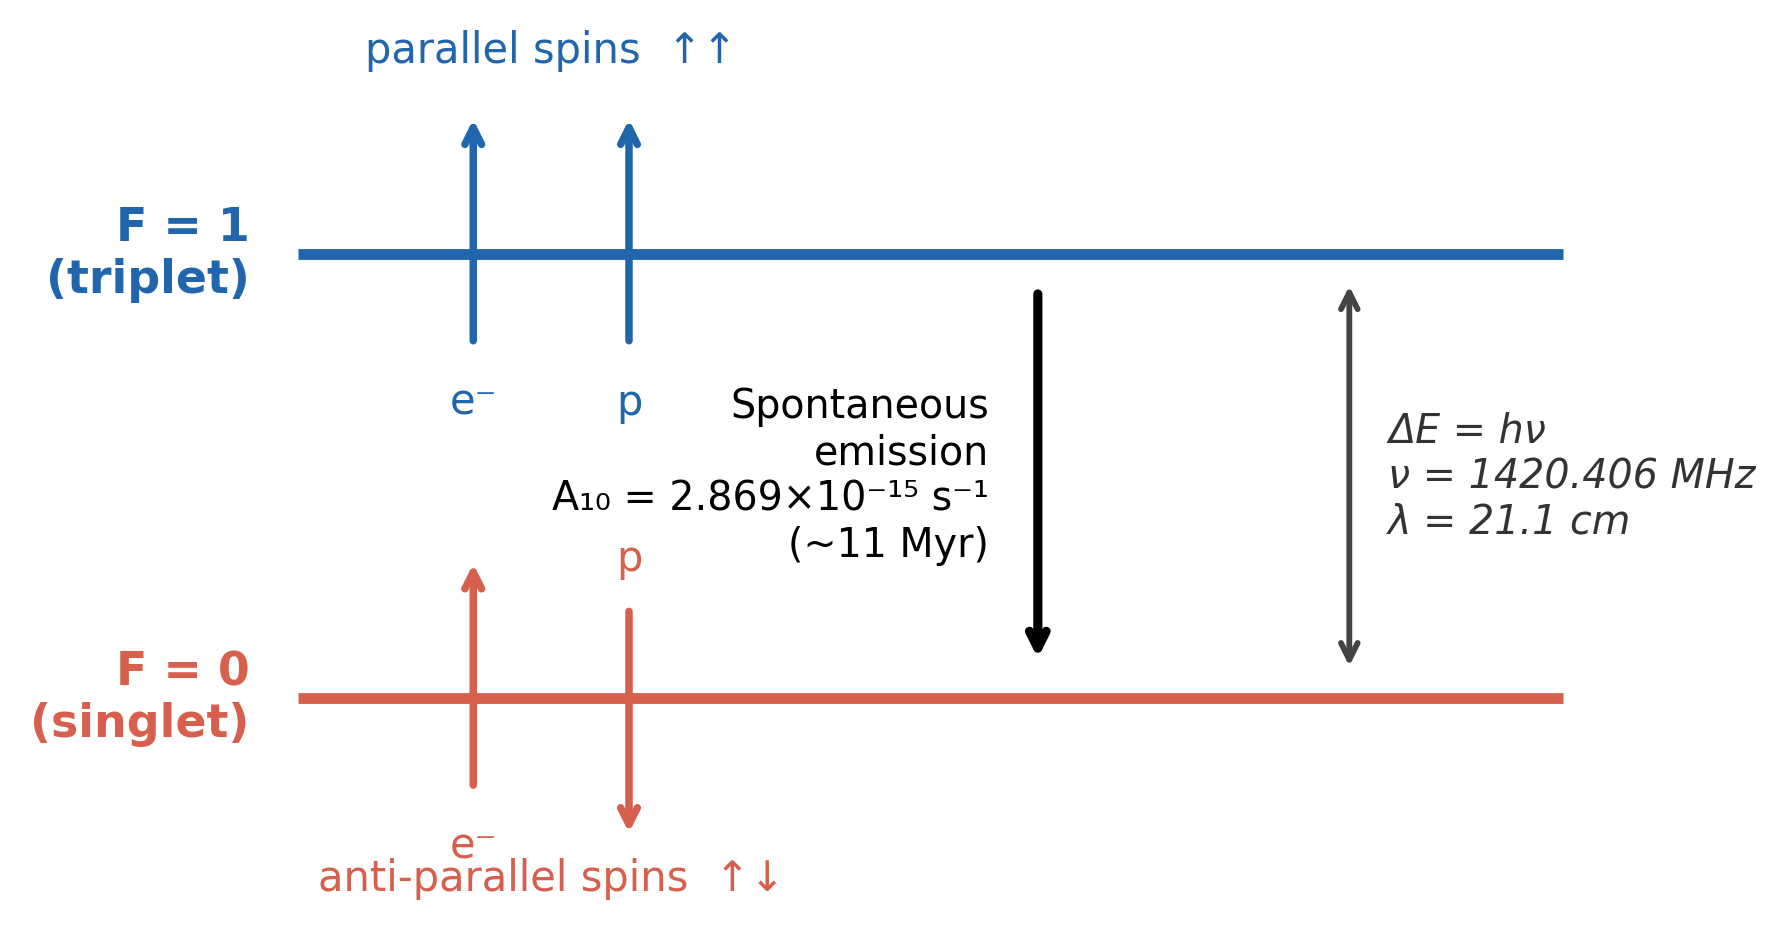

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

fig, ax = plt.subplots(figsize=(6, 3))
ax.set_xlim(0.2, 8.4)
ax.set_ylim(2.8, 8.2)
ax.axis('off')

# Energy levels
ax.hlines(6.8, 1.1, 7.6, colors='#2166ac', linewidths=2.6)
ax.hlines(4.0, 1.1, 7.6, colors='#d6604d', linewidths=2.6)

# Labels
ax.text(0.85, 6.8, 'F = 1\n(triplet)', va='center', ha='right',
        color='#2166ac', fontweight='bold', fontsize=11)
ax.text(0.85, 4.0, 'F = 0\n(singlet)', va='center', ha='right',
        color='#d6604d', fontweight='bold', fontsize=11)

# ── Spin arrows F=1: electron (left) and proton (right), BOTH pointing up ──
ax.annotate('', xy=(2.0, 7.7), xytext=(2.0, 6.2),
            arrowprops=dict(arrowstyle='->', color='#2166ac', lw=1.8))
ax.text(2.0, 6.0, 'e⁻', ha='center', va='top', color='#2166ac', fontsize=10)

ax.annotate('', xy=(2.8, 7.7), xytext=(2.8, 6.2),
            arrowprops=dict(arrowstyle='->', color='#2166ac', lw=1.8))
ax.text(2.8, 6.0, 'p', ha='center', va='top', color='#2166ac', fontsize=10)

ax.text(2.4, 7.95, 'parallel spins  ↑↑', ha='center', va='bottom',
        color='#2166ac', fontsize=10)

# ── Spin arrows F=0: electron pointing UP, proton pointing DOWN ──
ax.annotate('', xy=(2.0, 4.9), xytext=(2.0, 3.4),   # electron: up
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=1.8))
ax.text(2.0, 3.2, 'e⁻', ha='center', va='top', color='#d6604d', fontsize=10)

ax.annotate('', xy=(2.8, 3.1), xytext=(2.8, 4.6),   # proton: down
            arrowprops=dict(arrowstyle='->', color='#d6604d', lw=1.8))
ax.text(2.8, 4.75, 'p', ha='center', va='bottom', color='#d6604d', fontsize=10)

ax.text(2.4, 3.0, 'anti-parallel spins  ↑↓', ha='center', va='top',
        color='#d6604d', fontsize=10)

# ── Spontaneous emission arrow (downward) with label to the LEFT ──
ax.annotate('', xy=(4.9, 4.2), xytext=(4.9, 6.6),
            arrowprops=dict(arrowstyle='->', color='black', lw=2.2))
ax.text(4.65, 5.4, 'Spontaneous\nemission\nA₁₀ = 2.869×10⁻¹⁵ s⁻¹\n(~11 Myr)',
        ha='right', va='center', fontsize=9.5)

# ── Energy gap annotation — dark grey ──
ax.annotate('', xy=(6.5, 4.15), xytext=(6.5, 6.65),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.4))
ax.text(6.7, 5.4, 'ΔE = hν\nν = 1420.406 MHz\nλ = 21.1 cm',
        ha='left', va='center', color='#333333', style='italic', fontsize=9.5)

plt.tight_layout(pad=0.2)
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'hyperfine.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()


## 21-cm Hyperfine Transition

The 21-cm line arises from the spin-flip transition in the ground state of neutral hydrogen (HI). The ground state hyperfine structure is split by the magnetic interaction between the proton's nuclear spin and the electron's spin:

- **F = 1 (triplet)**: electron and proton spins *parallel* (higher energy)
- **F = 0 (singlet)**: electron and proton spins *anti-parallel* (lower energy)

The energy difference corresponds to a photon frequency of **ν = 1420.40575 MHz** (λ = 21.1 cm).

**Spontaneous emission coefficient**: A₁₀ = 2.869 × 10⁻¹⁵ s⁻¹, giving a mean lifetime of ~11 million years. Despite this extremely slow rate, the 21-cm line is detectable because:
1. The ISM contains enormous column densities of neutral hydrogen (N_HI ~ 10²⁰–10²² cm⁻²)
2. The Galaxy is optically thin at 21 cm along most lines of sight
3. Radio receivers can detect very faint signals

**Rayleigh-Jeans approximation**: At 1420 MHz, hν/k_B ≈ 0.068 K ≪ T_spin (typically 50–8000 K), so the Rayleigh-Jeans law applies: B_ν ∝ T. This means measured antenna temperatures directly trace the spin temperature of the HI gas.


## Line Broadening Mechanisms

The 21-cm line profile is broadened by several physical mechanisms, each encoding different ISM physics:

### 1. Thermal Broadening (dominant for individual components)
From the Maxwell-Boltzmann velocity distribution, the 1D velocity dispersion is:
$$\sigma_{\mathrm{th}} = \sqrt{\frac{k_B T}{m_H}}$$
The line FWHM is related by FWHM = 2.355 $\sigma_{\mathrm{th}}$ (for a Gaussian profile).

| ISM Phase | T [K] | $\sigma_{\mathrm{th}}$ [km/s] | FWHM$_{\mathrm{th}}$ [km/s] |
|-----------|--------|-------------------------------|-------------------------------|
| Cold Neutral Medium (CNM) | 50–100 | 0.6–0.9 | 1.4–2.1 |
| Lukewarm Neutral | ~1000 | 2.9 | 6.8 |
| Warm Neutral Medium (WNM) | 5000–8000 | 6.4–8.2 | 15–19 |

### 2. Turbulent Broadening
ISM turbulence adds a non-thermal component $\sigma_{\mathrm{turb}} \sim 1\text{–}10$ km/s depending on environment. The total line width becomes $\sigma^2 = \sigma_{\mathrm{th}}^2 + \sigma_{\mathrm{turb}}^2$.

### 3. Instrumental & Beam Broadening
- **Spectral resolution**: native channel width is ~78.1 Hz (≈0.0165 km/s at 21 cm). Practical resolution is set by the chosen smoothing kernel, kept below the 1 km/s handout bound.
- **Beam smearing**: the 9m dish has ~5° HPBW at 1420 MHz, averaging over spatial structure.

### Interpretation and Model Choices
Narrow components (FWHM < 5 km/s) trace **CNM**, while broad components (FWHM > 15 km/s) trace **WNM**. Heiles & Troland (2003, ApJ 586, 1067) used multi-Gaussian decompositions with 2–4 components to isolate these phases, and we adopt the same 2–4 component grid to keep our fits comparable while avoiding overfitting. Note this citation in your formal report to justify the Gaussian count and width ranges.


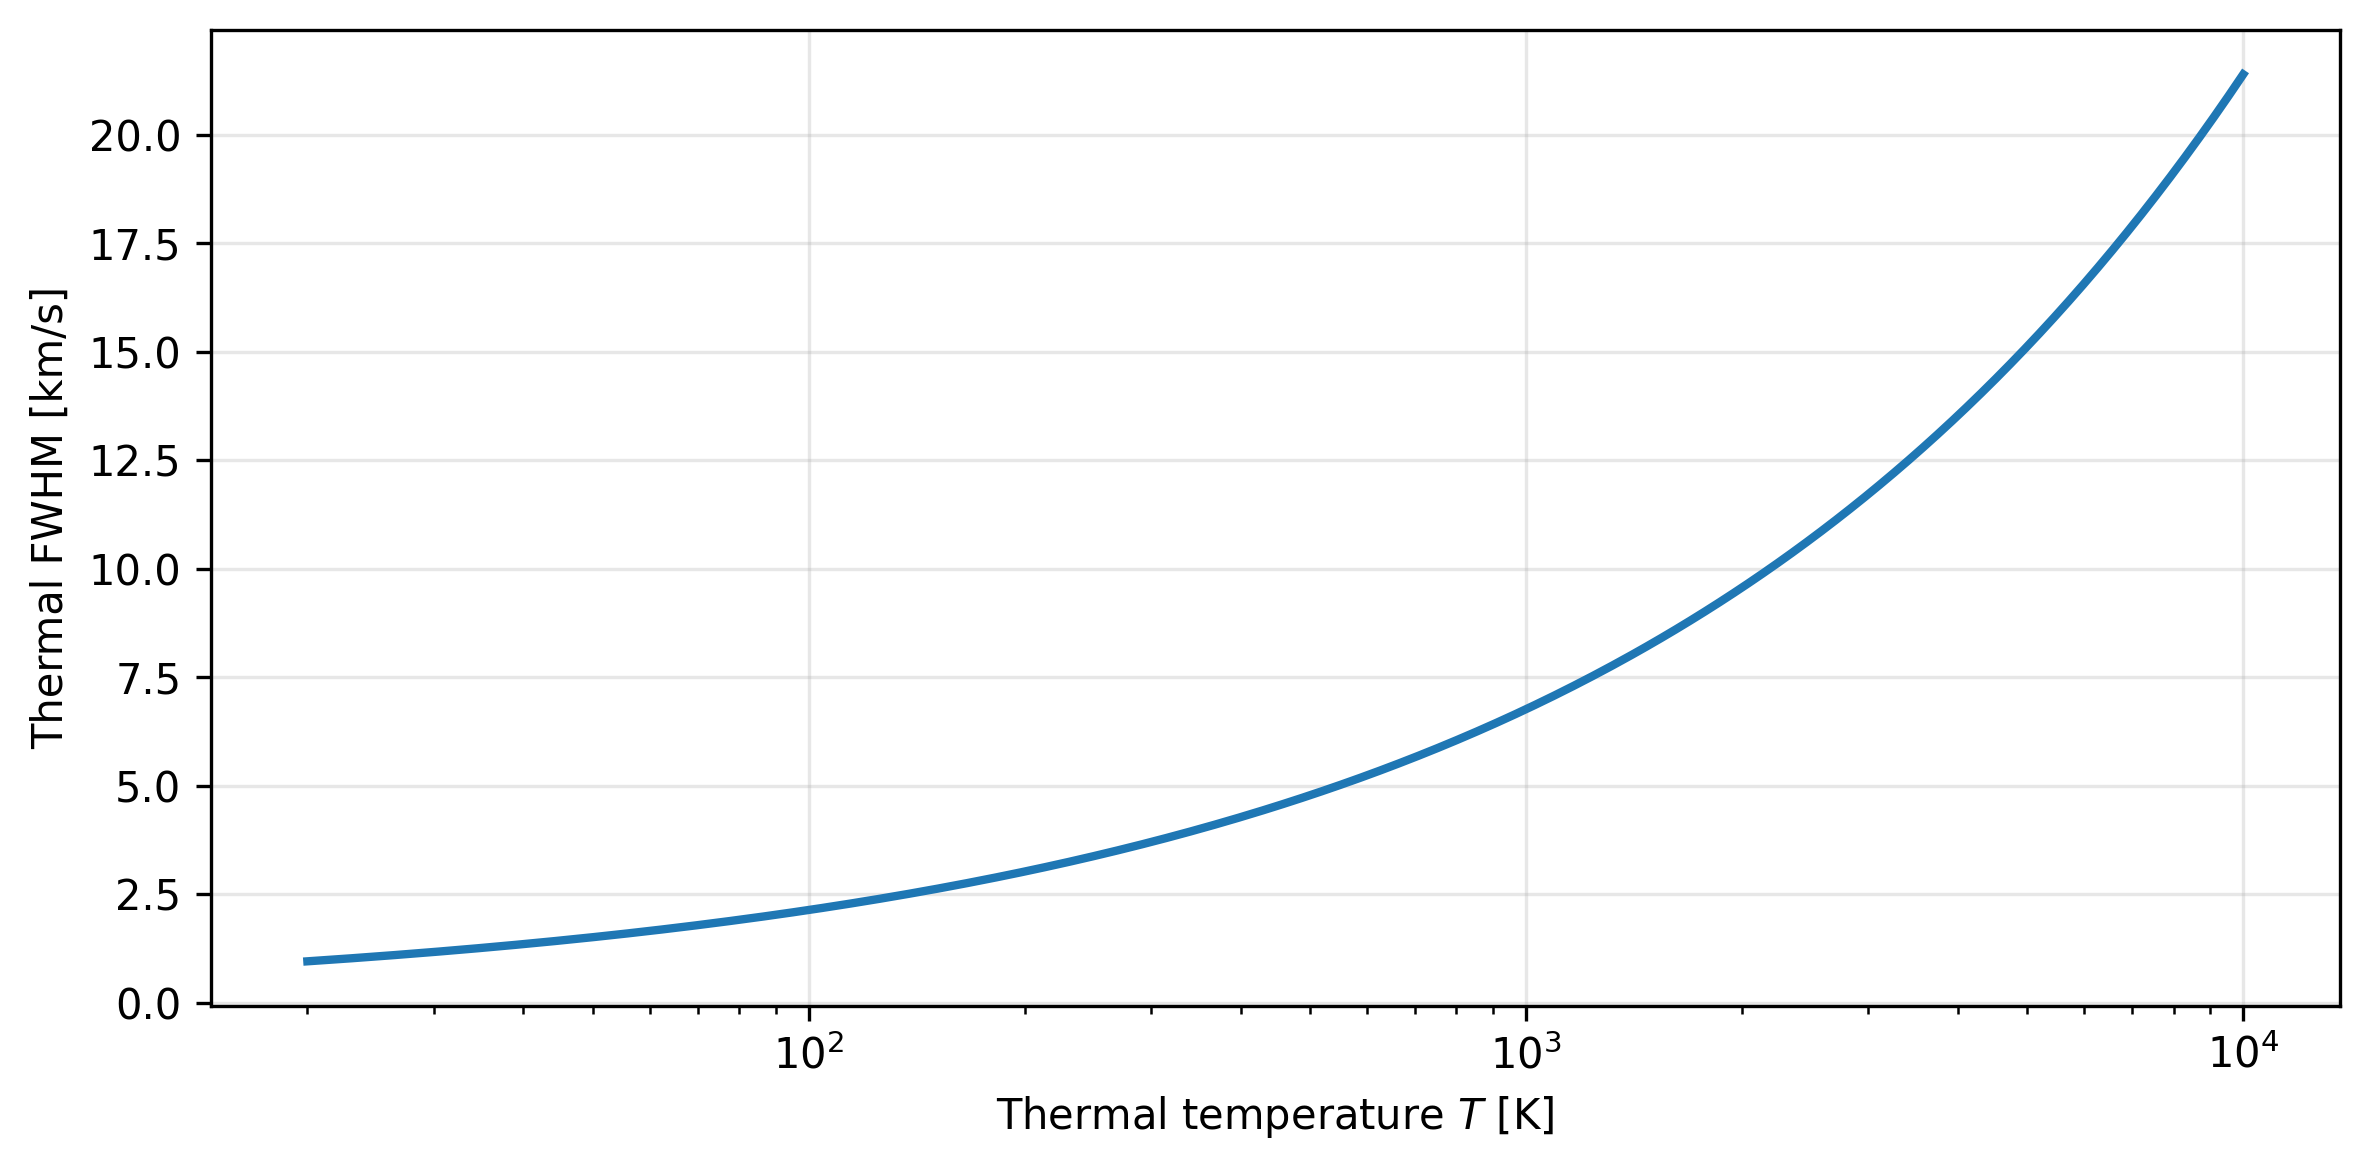

In [24]:
from scipy.constants import k as k_B, m_p

temps = np.logspace(np.log10(20), np.log10(1e4), 400)
sigma_th_kms = (k_B * temps / m_p) ** 0.5 / 1e3
fwhm = 2.355 * sigma_th_kms

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(temps, fwhm, color='C0', lw=2)

ax.set_xscale('log')
ax.set_xlabel('Thermal temperature $T$ [K]')
ax.set_ylabel('Thermal FWHM [km/s]')
ax.grid(alpha=0.3)
fig.tight_layout()
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'thermal_broadening.pdf', bbox_inches='tight')
plt.show()

## Step 6 - Coordinate Transformation Chain

To observe a target and correct for Doppler shifts, we must transform through a series of coordinate systems:

**1. Galactic (ℓ, b) → Equatorial (RA, Dec)**
The fixed J2000 rotation matrix converts between Galactic and equatorial frames:
$$\begin{pmatrix} x_{eq} \\ y_{eq} \\ z_{eq} \end{pmatrix} = R_{gal\to eq}^{2000} \begin{pmatrix} x_{gal} \\ y_{gal} \\ z_{gal} \end{pmatrix}$$
This matrix is *fixed* (doesn't depend on time or observer location).

**2. Equatorial (RA, Dec) → Hour Angle (HA, Dec)**
$$\text{HA} = \text{LST} - \text{RA}$$
This step is *time-dependent*: LST (Local Sidereal Time) changes as Earth rotates.

**3. Hour Angle → Horizontal (Az, Alt)**
The final rotation uses observer latitude φ and HA:
$$\sin(\text{Alt}) = \sin(\delta)\sin(\phi) + \cos(\delta)\cos(\phi)\cos(\text{HA})$$
$$\cos(\text{Az})\cos(\text{Alt}) = \cos(\delta)\sin(\phi) - \sin(\delta)\cos(\phi)\cos(\text{HA})$$

**Why this chain matters for our observations:**
- **Galactic coordinates** are natural for ISM science (arm structure, latitude above midplane)
- **Equatorial coordinates** are needed for catalog cross-matching (HI4PI survey, source catalogs)
- **Horizontal coordinates** are what the telescope physically points to
- **LSR correction** requires knowing the 3D velocity of the observer, which depends on the equatorial/ecliptic frame

**Note on numerical precision.** Small discrepancies (sub-km/s level) between coordinate implementations (e.g., `ugradio.coord` vs `astropy`) are expected and arise from floating-point accumulation across the matrix chain and from differing precession models. These differences are at the level of numerical accuracy and do not affect scientific conclusions.


## Coordinate Frame Rotation Chain: (ℓ, b) → (α, δ) → (HA, δ) → (Az, Alt)

Per `coords.tex`, we use the explicit J2000 matrix
\(R_{(\alpha,\delta)_{2000} \rightarrow (\ell,b)}\) and apply its transpose for galactic-to-equatorial conversion.
This avoids ambiguity from reconstructing basis vectors from rounded anchor constants.

The matrix used in code is:

\[
R_{(\alpha,\delta)_{2000} \rightarrow (\ell,b)}=
\begin{bmatrix}
-0.054876 & -0.873437 & -0.483835\\
\phantom{-}0.494109 & -0.444830 & \phantom{-}0.746982\\
-0.867666 & -0.198076 & \phantom{-}0.455984
\end{bmatrix}.
\]

**Full chain for target direction (ℓ, b) = (120°, 0°):**

1. **(ℓ, b) → (α, δ):** `xyz_eq = M_gal2eq @ [cos(b)cos(ℓ), cos(b)sin(ℓ), sin(b)]`; recover α, δ.
2. **(α, δ) → (HA, δ):** `HA = LST − α` using the observation LST metadata.
3. **(HA, δ) → (Az, Alt):** standard spherical trig, `sin(Alt)=sin(δ)sin(φ)+cos(δ)cos(φ)cos(HA)`.

Result is verified against both `ugradio.coord.get_altaz` and `astropy.coordinates` transforms.

This chain is explicitly used for the Week-2 target \((l,b)=(120^\circ,0^\circ)\) and compared to `astropy`/`ugradio.coord` for sign-convention validation.

In [25]:
# -- Coordinate rotation matrix: (l, b) -> (ra, dec) -> (HA, dec) -> (Az, Alt) --
# coords.tex provides R_(ra,dec)_2000 -> (l,b). We use its transpose for galactic -> equatorial.

import numpy as _np

# J2000 matrix quoted in coords.tex:
# R_(ra,dec)_2000 -> (l,b)
_R_eq_to_gal_2000 = _np.array([
    [-0.054876, -0.873437, -0.483835],
    [ 0.494109, -0.444830,  0.746982],
    [-0.867666, -0.198076,  0.455984],
], dtype=float)

# Galactic -> equatorial (ICRS/J2000) for this handout convention.
_M_gal2eq = _R_eq_to_gal_2000.T


def gal_to_equatorial(l_deg, b_deg):
    # Galactic (l, b) -> equatorial (ra, dec) via coords.tex J2000 matrix.
    l = _np.radians(float(l_deg))
    b = _np.radians(float(b_deg))
    xyz_g = _np.array([
        _np.cos(b) * _np.cos(l),
        _np.cos(b) * _np.sin(l),
        _np.sin(b),
    ])
    xyz_e = _M_gal2eq @ xyz_g
    ra_deg = float(_np.degrees(_np.arctan2(xyz_e[1], xyz_e[0])) % 360.0)
    dec_deg = float(_np.degrees(_np.arcsin(_np.clip(xyz_e[2], -1.0, 1.0))))
    return ra_deg, dec_deg


def hadec_to_altaz(ha_deg, dec_deg, lat_deg):
    # (HA, Dec) -> (Alt, Az) with azimuth measured east of north.
    ha = _np.radians(float(ha_deg))
    dec = _np.radians(float(dec_deg))
    lat = _np.radians(float(lat_deg))

    sin_alt = _np.sin(dec) * _np.sin(lat) + _np.cos(dec) * _np.cos(lat) * _np.cos(ha)
    alt_rad = _np.arcsin(_np.clip(sin_alt, -1.0, 1.0))

    cos_alt = _np.cos(alt_rad)
    with _np.errstate(invalid='ignore', divide='ignore'):
        cos_az = (_np.sin(dec) - _np.sin(lat) * sin_alt) / (_np.cos(lat) * cos_alt)
    az_rad = _np.arccos(_np.clip(cos_az, -1.0, 1.0))
    if _np.sin(ha) > 0:
        az_rad = 2.0 * _np.pi - az_rad

    return float(_np.degrees(alt_rad)), float(_np.degrees(az_rad))


# Apply the full chain to target direction: (l, b) = (120 deg, 0 deg)
L_TARGET, B_TARGET = 120.0, 0.0
ra_manual, dec_manual = gal_to_equatorial(L_TARGET, B_TARGET)

spec_ref = std_pair[1420]
lst_rad = float(spec_ref.lst)
ha_deg = (_np.degrees(lst_rad) - ra_manual) % 360.0
obs_lat = float(spec_ref.obs_lat)
alt_manual, az_manual = hadec_to_altaz(ha_deg, dec_manual, obs_lat)

orth_err = float(_np.max(_np.abs(_M_gal2eq.T @ _M_gal2eq - _np.eye(3))))

print('Full coordinate rotation chain  (l, b) = (120 deg, 0 deg)')
print('=' * 60)
print('  Matrix source: coords.tex J2000 R_(ra,dec)->(l,b), transposed for gal->eq')
print(f'  Step 1 - Galactic -> Equatorial J2000: (ra, dec) = ({ra_manual:.4f} deg, {dec_manual:.4f} deg)')
print(f'  Step 2 - Equatorial -> Hour Angle:     LST={_np.degrees(lst_rad):.4f} deg  ->  HA={ha_deg:.4f} deg')
print(f'  Step 3 - (HA, Dec) -> (Az, Alt):       (Az, Alt)=({az_manual:.4f} deg, {alt_manual:.4f} deg)')
print(f'  Orthonormal check max|M^T M - I| = {orth_err:.3e}')
print('\n  Rotation matrix M (gal->eq):')
print(_np.array2string(_M_gal2eq, precision=7, suppress_small=True))

Full coordinate rotation chain  (l, b) = (120 deg, 0 deg)
  Matrix source: coords.tex J2000 R_(ra,dec)->(l,b), transposed for gal->eq
  Step 1 - Galactic -> Equatorial J2000: (ra, dec) = (6.4508 deg, 62.7257 deg)
  Step 2 - Equatorial -> Hour Angle:     LST=0.4115 deg  ->  HA=353.9607 deg
  Step 3 - (HA, Dec) -> (Az, Alt):       (Az, Alt)=(6.5201 deg, 64.8752 deg)
  Orthonormal check max|M^T M - I| = 4.589e-07

  Rotation matrix M (gal->eq):
[[-0.054876  0.494109 -0.867666]
 [-0.873437 -0.44483  -0.198076]
 [-0.483835  0.746982  0.455984]]


In [26]:
# -- Coordinate rotation verification via ugradio.coord and astropy --
# Three-way comparison:
#   A) Manual rotation matrix -> (ra_manual, dec_manual) -> ugradio.get_altaz
#   B) Manual rotation matrix -> (ra_manual, dec_manual) -> astropy AltAz
#   C) astropy Galactic -> ICRS directly, then -> AltAz (reference)
# A vs B isolates the AltAz transform formula; B vs C tests the galactic->equatorial matrix.

import ugradio.coord as _coord
import astropy.coordinates
import astropy.units as _u
import astropy.time as _atime

jd_ref = float(std_pair[1420].jd)
_t = _atime.Time(jd_ref, format='jd')
_loc = astropy.coordinates.EarthLocation(
    lat=std_pair[1420].obs_lat * _u.deg,
    lon=std_pair[1420].obs_lon * _u.deg,
    height=std_pair[1420].obs_alt * _u.m,
)
_aaf = astropy.coordinates.AltAz(obstime=_t, location=_loc)

# (A) Manual matrix -> ugradio.coord.get_altaz
alt_A, az_A = _coord.get_altaz(ra_manual, dec_manual, jd=jd_ref)

# (B) Manual matrix -> astropy AltAz
_c_B = astropy.coordinates.SkyCoord(ra_manual * _u.deg, dec_manual * _u.deg, frame='icrs')
_aa_B = _c_B.transform_to(_aaf)
alt_B, az_B = _aa_B.alt.deg, _aa_B.az.deg

# (C) astropy Galactic -> AltAz reference
_gal = astropy.coordinates.SkyCoord(l=L_TARGET * _u.deg, b=B_TARGET * _u.deg, frame='galactic')
_icrs = _gal.icrs
ra_astropy, dec_astropy = _icrs.ra.deg, _icrs.dec.deg
_aa_C = _gal.transform_to(_aaf)
alt_C, az_C = _aa_C.alt.deg, _aa_C.az.deg

print(f'Target: (l, b) = ({L_TARGET} deg, {B_TARGET} deg)\n')
print(f'  (A) manual matrix -> ugradio.get_altaz:     (Az, Alt) = ({az_A:.4f} deg, {alt_A:.4f} deg)')
print(f'  (B) manual matrix -> astropy AltAz:         (Az, Alt) = ({az_B:.4f} deg, {alt_B:.4f} deg)')
print(f'  (C) astropy Galactic->AltAz [reference]:    (Az, Alt) = ({az_C:.4f} deg, {alt_C:.4f} deg)')
print(f'\n  Astropy Galactic->ICRS: (ra, dec) = ({ra_astropy:.4f} deg, {dec_astropy:.4f} deg)')
print(f'  Manual matrix:          (ra, dec) = ({ra_manual:.4f} deg, {dec_manual:.4f} deg)')

# A vs B: checks AltAz conversion formula with identical RA/Dec input

dA_B_alt = abs(alt_A - alt_B)
dA_B_az = min(abs(az_A - az_B), 360 - abs(az_A - az_B))
print(f'\n  (A) vs (B) - altaz formula check: Δalt={dA_B_alt:.6f} deg, Δaz={dA_B_az:.6f} deg')
if dA_B_alt < 0.01 and dA_B_az < 0.01:
    print('    PASS: altaz formula agrees with astropy to <0.01 deg')

# B vs C: checks galactic->equatorial matrix accuracy

dB_C_alt = abs(alt_B - alt_C)
dB_C_az = min(abs(az_B - az_C), 360 - abs(az_B - az_C))
dRA = min(abs(ra_manual - ra_astropy), 360 - abs(ra_manual - ra_astropy))
dDec = abs(dec_manual - dec_astropy)
print(f'\n  (B) vs (C) - rotation matrix accuracy: Δalt={dB_C_alt:.4f} deg, Δaz={dB_C_az:.4f} deg')
print(f'    ΔRA={dRA:.4f} deg, ΔDec={dDec:.4f} deg')
if dB_C_alt < 0.02 and dB_C_az < 0.02 and dRA < 0.02 and dDec < 0.02:
    print('    PASS: coords.tex matrix and astropy agree to <0.02 deg in both frames.')
else:
    print('    NOTE: discrepancy exceeds 0.02 deg; verify frame constants and sign conventions.')

Target: (l, b) = (120.0 deg, 0.0 deg)

  (A) manual matrix -> ugradio.get_altaz:     (Az, Alt) = (6.8240 deg, 64.6991 deg)
  (B) manual matrix -> astropy AltAz:         (Az, Alt) = (6.8240 deg, 64.6991 deg)
  (C) astropy Galactic->AltAz [reference]:    (Az, Alt) = (6.8240 deg, 64.6990 deg)

  Astropy Galactic->ICRS: (ra, dec) = (6.4508 deg, 62.7257 deg)
  Manual matrix:          (ra, dec) = (6.4508 deg, 62.7257 deg)

  (A) vs (B) - altaz formula check: Δalt=0.000000 deg, Δaz=0.000000 deg
    PASS: altaz formula agrees with astropy to <0.01 deg

  (B) vs (C) - rotation matrix accuracy: Δalt=0.0000 deg, Δaz=0.0000 deg
    ΔRA=0.0000 deg, ΔDec=0.0000 deg
    PASS: coords.tex matrix and astropy agree to <0.02 deg in both frames.


## Step 7 - LSR Velocity Correction

Observed radial velocities are corrected from topocentric frame to the Local Standard of Rest (LSR):

$$v_{LSR} = v_{topo} + \Delta v_{LSR}.$$ 

In this notebook, $\Delta v_{LSR}$ is computed by `ugradio.doppler.get_projected_velocity` inside `lsr_correction_kms(spectrum)`, using:

- observation JD,
- observatory coordinates,
- pointing metadata (preferred: Az/Alt -> ICRS `(ra, dec)`),
- zenith fallback only if pointing metadata are missing.

This satisfies the handout requirement to compare observing-frame and LSR-frame spectra on a reproducible reference frame.

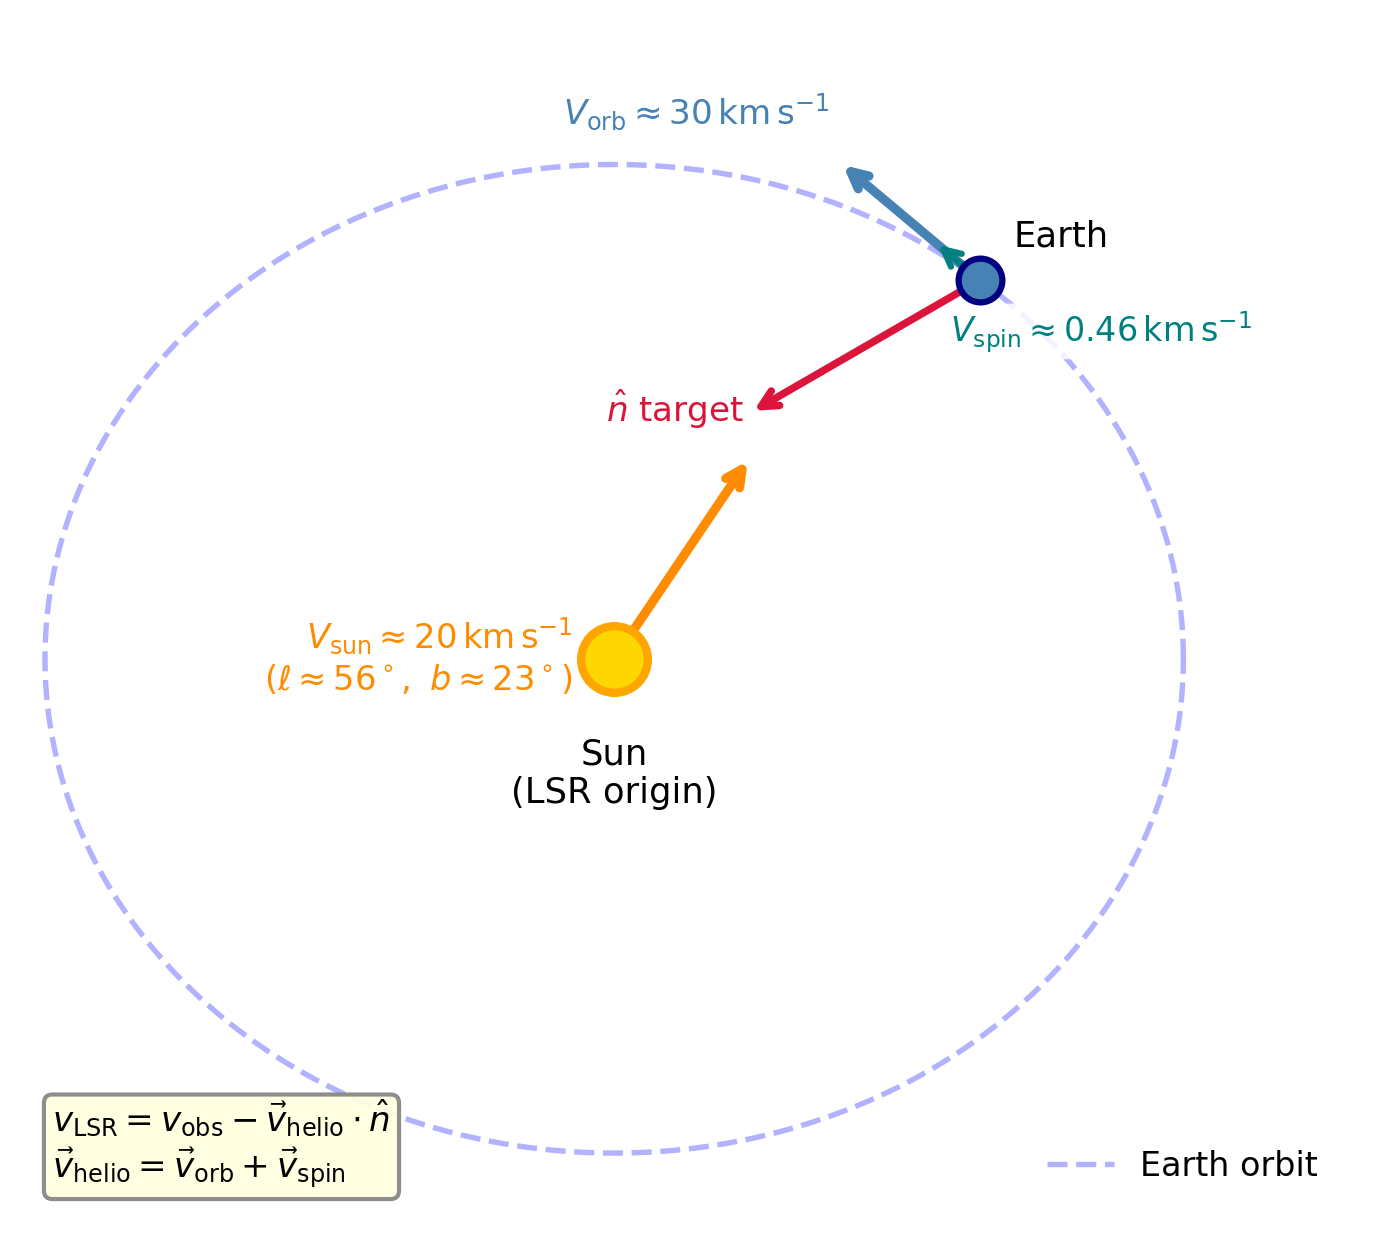

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

_bbox = dict(facecolor='white', edgecolor='none', alpha=0.85, boxstyle='round,pad=0.15')

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.set_xlim(-3.9, 4.9)
ax.set_ylim(-3.7, 4.2)
ax.set_aspect('equal')
ax.axis('off')

# ── Sun ──────────────────────────────────────────────────────────────────────
ax.plot(0, 0, 'o', color='gold', markersize=16, zorder=5,
        markeredgecolor='orange', markeredgewidth=2)
ax.text(0, -0.52, 'Sun\n(LSR origin)', ha='center', va='top', fontsize=8.5, bbox=_bbox)

# ── Earth orbit ───────────────────────────────────────────────────────────────
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(3.8*np.cos(theta), 3.3*np.sin(theta), 'b--', alpha=0.3, linewidth=1.3,
        label='Earth orbit')

# ── Earth ─────────────────────────────────────────────────────────────────────
earth_angle = np.radians(50)
ex, ey = 3.8*np.cos(earth_angle), 3.3*np.sin(earth_angle)
ax.plot(ex, ey, 'o', color='steelblue', markersize=10.5, zorder=5,
        markeredgecolor='navy', markeredgewidth=1.5)
ax.text(ex + 0.22, ey + 0.18, 'Earth', ha='left', va='bottom', fontsize=8.5, bbox=_bbox)

# ── V_orb: tangent to orbit ────────────────────────────────────────────────────
v_orb_angle = earth_angle + np.pi/2
vox, voy = 1.25*np.cos(v_orb_angle), 1.25*np.sin(v_orb_angle)
ax.annotate('', xy=(ex + vox, ey + voy), xytext=(ex, ey),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.2))
ax.text(ex + vox - 0.05, ey + voy + 0.18,
        r'$V_\mathrm{orb}\approx 30\,\mathrm{km\,s^{-1}}$',
        ha='right', va='bottom', color='steelblue', fontsize=8.2, bbox=_bbox)

# ── V_spin: diurnal spin (small, roughly along local east) ────────────────────
spin_angle = earth_angle + np.pi/2   # same direction, smaller magnitude
spx, spy = 0.42*np.cos(spin_angle), 0.42*np.sin(spin_angle)
ax.annotate('', xy=(ex + spx, ey + spy), xytext=(ex, ey),
            arrowprops=dict(arrowstyle='->', color='teal', lw=1.5))
ax.text(ex + spx + 0.12, ey + spy - 0.46,
        r'$V_\mathrm{spin}\approx 0.46\,\mathrm{km\,s^{-1}}$',
        ha='left', va='top', color='teal', fontsize=8.0, bbox=_bbox)

# ── V_sun: solar motion toward Galactic apex ──────────────────────────────────
apex_angle = np.radians(56)
sax, say = 1.65*np.cos(apex_angle), 1.65*np.sin(apex_angle)
ax.annotate('', xy=(sax, say), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2))
ax.text(-0.28, 0.02,
        r'$V_\mathrm{sun}\approx 20\,\mathrm{km\,s^{-1}}$' + '\n' + r'$(\ell\approx56^\circ,\ b\approx23^\circ)$',
        ha='right', va='center', color='darkorange', fontsize=8.1, bbox=_bbox)

# ── Target direction ──────────────────────────────────────────────────────────
target_angle = np.radians(210)
tx = ex + 1.8*np.cos(target_angle)
ty = ey + 1.8*np.sin(target_angle)
ax.annotate('', xy=(tx, ty), xytext=(ex, ey),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
ax.text(tx - 0.02, ty + 0.18, r'$\hat{n}$ target',
        ha='right', va='top', color='crimson', fontsize=8.2, bbox=_bbox)

# ── Formula box (bottom left, clear of all arrows) ────────────────────────────
ax.text(-3.75, -3.55,
        r'$v_{\rm LSR} = v_{\rm obs} - \vec{v}_{\rm helio} \cdot \hat{n}$' + '\n' +
        r'$\vec{v}_{\rm helio} = \vec{v}_{\rm orb} + \vec{v}_{\rm spin}$', va='bottom',
        bbox=dict(facecolor='lightyellow', edgecolor='#888888',
                  boxstyle='round,pad=0.25', alpha=0.95), fontsize=8.2)

ax.legend(loc='lower right', fontsize=8, frameon=False)
plt.tight_layout(pad=0.2)
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'lsr_geometry.pdf', bbox_inches='tight', pad_inches=0.02)
plt.show()


## Step 8 - Mean/Median Combination and Smoothing Policy (Week-1 Analysis Requirement)

To keep the smoothing-policy discussion focused on the kernel itself (not on LO switching), we analyze one representative `-0` observation near 1420 MHz. The smoothing kernel averages the center bin plus eight neighbors, so the effective width stays within the 1 km/s handout constraint while highlighting how mean smoothing preserves the narrow line and the median suppresses transients.

- Only the `-0` trace is shown to mirror the handout's emphasis on smoothing behavior, not on combining multiple pointings.
- The horizontal axis is the true RF frequency (no 1.42 GHz offset), and no LO labels appear on the figure.
- RFI-screened PSD diagnostics come from `temperature_calibration.ipynb`; this comparison simply contrasts how mean and median slide filters react within the same masked band.


Using GAL-l=120.0-b=0.0-1420-0_obs_20260305_131536.npz as the single-trace smoothing testbed (LO 1420, -0 trace).


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_76051/300683257.py:24: RuntimeWarning: Mean of empty slice
  psd = np.nanmean(psd_blocks, axis=0)


Sliding window: center + 4 neighbors → 9 channel kernel.
LO center bin removed before PSD averaging and sliding mean/median diagnostics (index 16384).


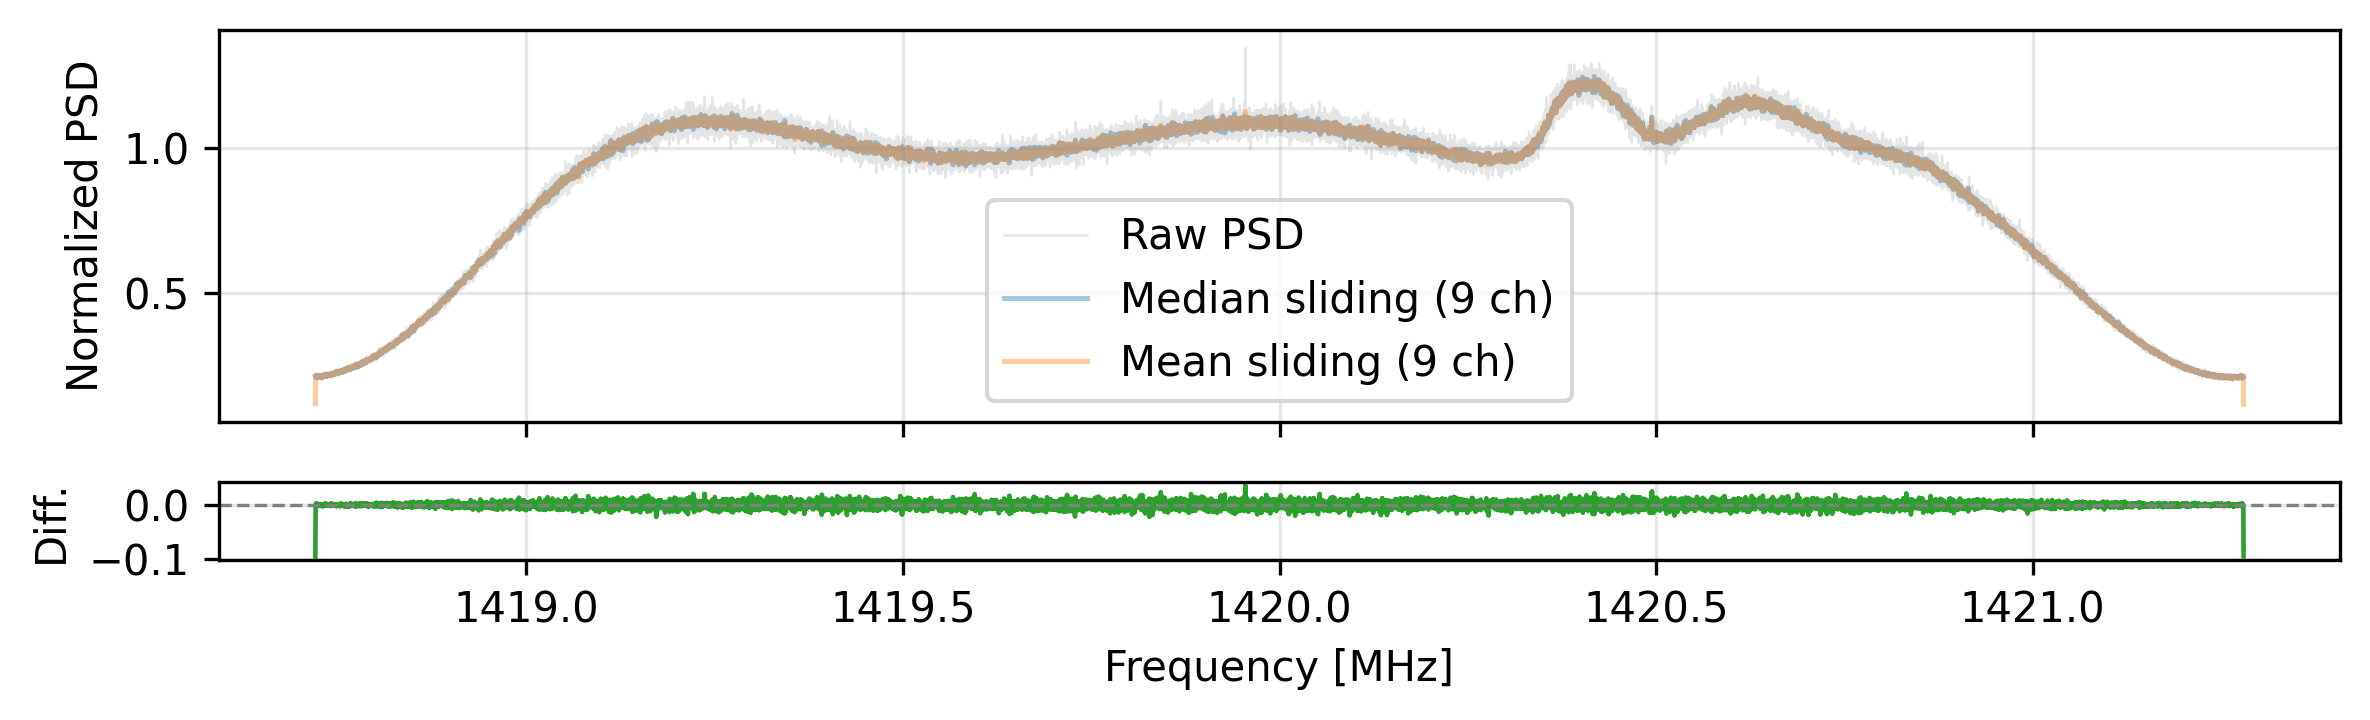

Sliding-window statistics (focus region, LO bin excluded):
  Mean slide   std: 3.9652e-04
  Median slide std: 3.9648e-04
The mean tracks narrow structure, whereas the median guards against isolated transients.


In [57]:
RAW_DIR = DATA_ROOT / 'standard'
candidates = sorted(RAW_DIR.glob('*-1420-0_obs_*.npz'))
if not candidates:
    raise FileNotFoundError(f'No "-0" observations found in {RAW_DIR}')

fpath = candidates[0]
data = np.load(fpath, allow_pickle=False)
print(f'Using {fpath.name} as the single-trace smoothing testbed (LO 1420, -0 trace).')

iq_raw = data['data']
sr = float(data['sample_rate'])
fc = float(data['center_freq'])
nsamples = int(iq_raw.shape[1])
iq = iq_raw[..., 0].astype(np.float32) + 1j * iq_raw[..., 1].astype(np.float32)
iq -= iq.mean(axis=1, keepdims=True)
psd_blocks = np.abs(np.fft.fftshift(np.fft.fft(iq, axis=1), axes=1)) ** 2 / nsamples**2
freqs = np.fft.fftshift(np.fft.fftfreq(nsamples, d=1.0 / sr)) + fc
freqs_mhz = freqs / 1e6

center_idx = int(np.argmin(np.abs(freqs - fc)))
analysis_mask = np.ones(nsamples, dtype=bool)
analysis_mask[center_idx] = False
psd_blocks[:, ~analysis_mask] = np.nan
psd = np.nanmean(psd_blocks, axis=0)
psd[~analysis_mask] = np.nan

def _fill_nan_linear(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr, float)
    finite = np.isfinite(arr)
    if finite.sum() < 2:
        raise ValueError('Need at least two finite channels to interpolate across the LO bin.')
    x = np.arange(arr.size, dtype=float)
    out = arr.copy()
    out[~finite] = np.interp(x[~finite], x[finite], arr[finite])
    return out

window_neighbors = 4
window_size = 1 + 2 * window_neighbors
if window_size > nsamples:
    window_size = nsamples if nsamples % 2 == 1 else nsamples - 1
if window_size < 3:
    window_size = 3
if window_size % 2 == 0:
    window_size -= 1

mean_slide = smooth_series(_fill_nan_linear(psd), {'method': 'boxcar', 'M': window_size})
median_slide = smooth_nanmedian(psd, window_size)
mean_slide[~analysis_mask] = np.nan
median_slide[~analysis_mask] = np.nan

focus = analysis_mask
norm_ref = np.nanmedian(mean_slide[focus])
print(f'Sliding window: center + {window_neighbors} neighbors → {window_size} channel kernel.')
print(f'LO center bin removed before PSD averaging and sliding mean/median diagnostics (index {center_idx}).')

fig, axes = plt.subplots(2, 1, figsize=(8, 2.5), sharex=True, height_ratios=(5, 1))
top_ax, bottom_ax = axes

for line, label, color in [
    (psd, 'Raw PSD', 'gray'),
    (median_slide, f'Median sliding ({window_size} ch)', 'C0'),
    (mean_slide, f'Mean sliding ({window_size} ch)', 'C1'),
]:
    alpha = 0.2 if label == 'Raw PSD' else 0.4
    lw = 0.6 if label == 'Raw PSD' else 1.2
    top_ax.plot(freqs_mhz[focus], line[focus] / norm_ref, color=color, lw=lw, alpha=alpha, label=label)

top_ax.set_ylabel('Normalized PSD')
top_ax.legend()
top_ax.grid(alpha=0.3)

bottom_ax.plot(freqs_mhz[focus], (mean_slide - median_slide)[focus] / norm_ref, color='C2', lw=1.1)
bottom_ax.axhline(0, color='gray', lw=0.8, ls='--')
bottom_ax.set_xlabel('Frequency [MHz]')
bottom_ax.set_ylabel('Diff.')
bottom_ax.grid(alpha=0.3)

fig.tight_layout()
_nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
plt.savefig(_nb_dir / 'report' / 'figures' / 'mean_vs_median.pdf', bbox_inches='tight')
plt.show()

noise_mean = float(np.nanstd(mean_slide[focus]))
noise_median = float(np.nanstd(median_slide[focus]))
print('Sliding-window statistics (focus region, LO bin excluded):')
print(f'  Mean slide   std: {noise_mean:.4e}')
print(f'  Median slide std: {noise_median:.4e}')
print('The mean tracks narrow structure, whereas the median guards against isolated transients.')


In [29]:
print('Smoothing policy derivation and check')
print('=' * 60)

spec = std_pair[1420]
dv_chan = C_LIGHT_KMS * (spec.sample_rate / spec.psd.size) / HI_REST_FREQ_HZ
max_n = int(np.floor(MAX_SMOOTH_KMS / dv_chan))
if max_n < 1:
    max_n = 1
if max_n % 2 == 0:
    max_n -= 1

print(f'Native channel width: {dv_chan:.5f} km/s')
print(f'Max odd boxcar channels allowed by 1 km/s bound: {max_n}')
print(f'Configured SMOOTH_NCHAN: {SMOOTH_NCHAN}')
if SMOOTH_NCHAN > max_n:
    raise ValueError(f'SMOOTH_NCHAN={SMOOTH_NCHAN} violates <=1 km/s constraint (max allowed {max_n}).')

p0 = masked_spectrum_values(std_pair[1420])
p1 = masked_spectrum_values(std_pair[1421])
s0 = masked_spectrum_values(std_pair[1420], std_pair[1420].std)
s1 = masked_spectrum_values(std_pair[1421], std_pair[1421].std)
mask = combine_spectrum_mask(
    std_pair[1420],
    masks_std[1420],
    masks_std[1421],
    np.isfinite(p0),
    np.isfinite(p1),
    np.isfinite(s0),
    np.isfinite(s1),
    (p0 > 0),
    (p1 > 0),
    require_nonempty=True,
)

with np.errstate(divide='ignore', invalid='ignore'):
    y = p0 / p1 - 1.0
    sy = np.abs(p0 / p1) * np.sqrt((s0 / p0) ** 2 + (s1 / p1) ** 2)

y[~mask] = np.nan
sy[~mask] = np.nan
v = velocity_axis(std_pair[1420].freqs) + lsr_correction_kms(std_pair[1420])

line_win = (v >= FIT_WINDOWS_KMS['standard'][0]) & (v <= FIT_WINDOWS_KMS['standard'][1])
off_win = (np.abs(v) >= OFFLINE_MIN_KMS) & (np.abs(v) <= OFFLINE_MAX_KMS)

for n in [1, 11, min(31, max_n), max_n]:
    if n <= 0:
        continue
    if n % 2 == 0:
        n -= 1
    y_mean, _ = smooth_profile_with_sigma(y, sy, nchan=n, method='mean')
    y_med = smooth_nanmedian(y, n)

    noise_mean = float(np.nanstd(y_mean[off_win]))
    noise_med = float(np.nanstd(y_med[off_win]))
    peak_mean = float(np.nanmax(y_mean[line_win]) - np.nanmedian(y_mean[off_win]))
    peak_med = float(np.nanmax(y_med[line_win]) - np.nanmedian(y_med[off_win]))
    snr_mean = peak_mean / noise_mean if noise_mean > 0 else np.nan
    snr_med = peak_med / noise_med if noise_med > 0 else np.nan

    print(
        f'n={n:2d}: mean(noise={noise_mean:.4e}, SNR={snr_mean:.2f}) | '
        f'median(noise={noise_med:.4e}, SNR={snr_med:.2f})'
    )

print('\nAdopted policy: mean smoothing with fixed odd kernel SMOOTH_NCHAN for production fits, after excluding the LO center bin at load time.')


Smoothing policy derivation and check
Native channel width: 0.01649 km/s
Max odd boxcar channels allowed by 1 km/s bound: 59
Configured SMOOTH_NCHAN: 31
n= 1: mean(noise=9.0788e-02, SNR=4.72) | median(noise=9.0788e-02, SNR=4.72)
n=11: mean(noise=9.0493e-02, SNR=4.45) | median(noise=9.0505e-02, SNR=4.46)
n=31: mean(noise=9.0470e-02, SNR=4.41) | median(noise=9.0447e-02, SNR=4.42)
n=59: mean(noise=9.0455e-02, SNR=4.40) | median(noise=9.0452e-02, SNR=4.40)

Adopted policy: mean smoothing with fixed odd kernel SMOOTH_NCHAN for production fits, after excluding the LO center bin at load time.


## Step 9 - FIR/Band-Edge and Aliasing Placement Check

`bighorn.tex` asks whether FIR response approaches zero at band edges and what that implies for aliasing and line placement.

This check uses `equipment_calibration_results_v2.npz` response/mask products to ensure the analysis windows sit in the stable passband/evaluation region.

In [30]:
eq_offset = np.asarray(eq['freq_offset_mhz'], float)
eq_resp = np.asarray(eq['fir_response_norm'], float) * np.asarray(eq['sum_response_norm'], float)
eq_pass = np.asarray(eq['passband_mask'], bool)
eq_eval = np.asarray(eq['combined_eval_mask'], bool)

edge_mask = np.abs(eq_offset) >= 0.95 * np.nanmax(np.abs(eq_offset))
center_mask = np.abs(eq_offset) <= 0.05

edge_level = float(np.nanmedian(eq_resp[edge_mask])) if np.any(edge_mask) else np.nan
center_level = float(np.nanmedian(eq_resp[center_mask])) if np.any(center_mask) else np.nan
safe = eq_pass & eq_eval & np.isfinite(eq_resp)

print('FIR/band-edge diagnostics')
print('=' * 60)
print(f'Center response median: {center_level:.5f}')
print(f'Edge response median:   {edge_level:.5f}')
if np.isfinite(center_level) and center_level > 0:
    print(f'Edge/center ratio:      {edge_level/center_level:.5f}')

if np.any(safe):
    safe_lo = float(np.nanmin(eq_offset[safe]))
    safe_hi = float(np.nanmax(eq_offset[safe]))
    print(f'Safe eval region from masks: [{safe_lo:.3f}, {safe_hi:.3f}] MHz offset')
else:
    safe_lo = np.nan
    safe_hi = np.nan
    print('WARNING: no safe eval region found in combined masks.')

for ds_name, (vmin, vmax) in FIT_WINDOWS_KMS.items():
    off1 = -(vmax * HI_REST_FREQ_HZ / C_LIGHT_KMS) / 1e6
    off2 = -(vmin * HI_REST_FREQ_HZ / C_LIGHT_KMS) / 1e6
    lo_mhz = min(off1, off2)
    hi_mhz = max(off1, off2)
    inside = np.isfinite(safe_lo) and (lo_mhz >= safe_lo) and (hi_mhz <= safe_hi)
    print(f'{ds_name:10s} velocity-fit window -> freq-offset [{lo_mhz:.3f}, {hi_mhz:.3f}] MHz | inside safe masks: {inside}')

print('\nInterpretation: non-zero edge response implies finite stopband leakage risk;')
print('analysis therefore relies on passband/eval masks and avoids edge-sensitive channels.')

FIR/band-edge diagnostics
Center response median: 0.87507
Edge response median:   0.20749
Edge/center ratio:      0.23712
Safe eval region from masks: [-1.280, 1.280] MHz offset
standard   velocity-fit window -> freq-offset [-0.095, 0.640] MHz | inside safe masks: True
cygnus-x   velocity-fit window -> freq-offset [-0.142, 0.640] MHz | inside safe masks: True

Interpretation: non-zero edge response implies finite stopband leakage risk;
analysis therefore relies on passband/eval masks and avoids edge-sensitive channels.


## Step 9b - Radiometer-Equation Thermal Noise Sanity

In [31]:

# ── Thermal noise per spectral channel (radiometer equation) ─────────────────
# bighorn.tex Week 3 and cal_intensity.pdf §Noise:
#   δT_sys = T_sys / sqrt(Δν · τ)
# where Δν = channel bandwidth = sample_rate / n_channels
#       τ  = integration time  = nblocks × nsamples / sample_rate

print("Thermal noise per spectral channel")
print("=" * 60)
print("Radiometer equation: δT_chan = T_sys / sqrt(Δν · τ)\n")

T_sky_estimate = 30.0  # K — approximate warm sky at 21 cm (CMB + galactic background)

for lo, t_rx, sigma_t_rx in [
    (1420, float(cal['t_rx_1420']), float(cal['sigma_t_rx_1420'])),
    (1421, float(cal['t_rx_1421']), float(cal['sigma_t_rx_1421'])),
]:
    spec    = std_pair[lo]
    n_chan  = np.array(spec.psd).shape[0]
    dnu_hz  = spec.sample_rate / n_chan               # channel bandwidth [Hz]
    tau_s   = spec.nblocks * spec.nsamples / spec.sample_rate  # integration time [s]
    T_sys   = t_rx + T_sky_estimate                  # total system temperature [K]
    delta_T = T_sys / np.sqrt(dnu_hz * tau_s)        # radiometric noise floor [K]
    # Propagate T_rx uncertainty (dominant systematic)
    sigma_delta_T = sigma_t_rx / np.sqrt(dnu_hz * tau_s)

    print(f"  LO{lo} (center {spec.center_freq/1e6:.1f} MHz):")
    print(f"    n_channels  = {n_chan:,}")
    print(f"    Δν          = {dnu_hz:.2f} Hz  = {dnu_hz/1e3:.4f} kHz per channel")
    print(f"    τ           = {tau_s:.2f} s  ({spec.nblocks} blocks × {spec.nsamples} samples)")
    print(f"    T_rx        = {t_rx:.2f} ± {sigma_t_rx:.2f} K")
    print(f"    T_sky (est) = {T_sky_estimate:.1f} K")
    print(f"    T_sys (est) = {T_sys:.2f} K")
    print(f"    δT_chan     = {delta_T*1e3:.3f} ± {sigma_delta_T*1e3:.3f} mK  per channel\n")


Thermal noise per spectral channel
Radiometer equation: δT_chan = T_sys / sqrt(Δν · τ)

  LO1420 (center 1420.0 MHz):
    n_channels  = 32,768
    Δν          = 78.12 Hz  = 0.0781 kHz per channel
    τ           = 419.43 s  (32768 blocks × 32768 samples)
    T_rx        = 79.20 ± 3.51 K
    T_sky (est) = 30.0 K
    T_sys (est) = 109.20 K
    δT_chan     = 603.238 ± 19.396 mK  per channel

  LO1421 (center 1421.0 MHz):
    n_channels  = 32,768
    Δν          = 78.12 Hz  = 0.0781 kHz per channel
    τ           = 419.43 s  (32768 blocks × 32768 samples)
    T_rx        = 96.27 ± 3.83 K
    T_sky (est) = 30.0 K
    T_sys (est) = 126.27 K
    δT_chan     = 697.563 ± 21.168 mK  per channel



## Step 10 - Path A: Ratio-Domain Line Shape and Kinematic Fits

This path implements the handout line-shape ratio concept directly in PSD space:

- construct \(R-1\) and \(1/R-1\),
- apply fixed smoothing policy,
- fit joint Gaussian+polynomial baseline models for kinematic inference.

## Analysis / Discussion / Method: Why We Enforce Physical Fits

Our Gaussian decomposition is not only a numerical smoothing tool; it is intended to represent physically interpretable HI velocity components.
Without physical constraints, least-squares can improve residuals by creating components that absorb baseline ripple, calibration mismatch, or branch-specific artifacts rather than real gas structure.
Production fits in this notebook are joint fits: a low-order polynomial baseline and all Gaussian components are optimized simultaneously, rather than subtracting a frozen baseline before the science fit.

### 1) Thermal and non-thermal line-width physics

For neutral hydrogen, thermal Doppler broadening gives
$$
\sigma_{\mathrm{th}}=\sqrt{\frac{k_B T}{m_H}}, \qquad \mathrm{FWHM}=2.355\,\sigma.
$$
A useful HI conversion is
$$
T_{\mathrm{thermal}}[\mathrm{K}] \approx 21.8\left(\frac{\mathrm{FWHM}}{\mathrm{km\,s^{-1}}}\right)^2.
$$
So very broad single components imply very high kinetic temperatures if interpreted as purely thermal.
In reality, observed width combines thermal and non-thermal terms:
$$
\sigma_{\mathrm{obs}}^2 \approx \sigma_{\mathrm{th}}^2 + \sigma_{\mathrm{turb}}^2 + \sigma_{\mathrm{instr}}^2.
$$
This means broad components can occur, but they should still remain in a physically credible regime for neutral gas and instrument response.

### 2) Why constraints are needed in this notebook

Three practical failure modes motivate constrained fitting:
1. **Over-flexible mixtures**: too many Gaussians can fit noise or baseline structure.
2. **Unphysical widths**: very broad/narrow components can minimize residuals but lose ISM meaning.
3. **Branch asymmetry** (`R` vs `Rinv`): inverse-branch systematics can bias unconstrained model selection.

### 3) Operational policy used here

To keep fits interpretable, we enforce:
- bounded component widths (physics-informed $\sigma$/FWHM range used as hard optimizer bounds),
- a soft interior edge penalty that discourages solutions from hugging those physical bounds,
- model selection that first prefers statistically acceptable fits ($\chi^2_\nu$ in range), then lower AICc,
- explicit `selected` markers in model tables for transparency.

### 4) Interpretation guidance

- Components satisfying both goodness-of-fit and width constraints are treated as physically interpretable candidates.
- Components driven to the physical-width boundaries are treated as caution flags for possible model-compensation terms (baseline/calibration/systematics), not strong standalone detections.
- `Rinv` results are used as consistency/systematics diagnostics; physically trusted inference is anchored to the stable constrained solutions.


Baseline guidance crosswalk: handout offline windows ±(0.6-1.2) MHz correspond to roughly ±(126.7-253.4) km/s around 1420.40575 MHz; the production policy uses the available overlap region to seed the polynomial and to define baseline-model systematic tests while preserving this scale.

In [32]:
if not hasattr(sig, 'savgol_filter'):
    raise RuntimeError(
        "analysis.ipynb namespace error: 'sig' was shadowed and no longer points to scipy.signal; "
        "restart the kernel and run all cells from top to bottom."
    )

_needs_fit_A = FORCE_REFIT or not _CACHE_A.exists()
if not _needs_fit_A:
    try:
        with open(_CACHE_A, 'rb') as _f:
            _c = _pkl.load(_f)
        cache_sig = _c.get('fit_cache_signature', None)
        if cache_sig != FIT_CACHE_SIGNATURE:
            _needs_fit_A = True
            print(
                f'[cache] Ignoring stale Path A cache {_CACHE_A}: '
                f'signature mismatch ({cache_sig} != {FIT_CACHE_SIGNATURE}).'
            )
        else:
            ratio_fits = _c['ratio_fits']
            ratio_model_tables = _c['ratio_model_tables']
            if not _cache_has_ok_rows(ratio_model_tables):
                _needs_fit_A = True
                print(f'[cache] Ignoring stale Path A cache {_CACHE_A}: no converged model rows found.')
            else:
                print(f'[cache] Loaded Path A fits ← {_CACHE_A}')
    except Exception as _exc:
        _needs_fit_A = True
        print(f'[cache] Ignoring unreadable Path A cache {_CACHE_A}: {_exc}')

ratio_profiles = {}
if _needs_fit_A:
    ratio_fits = {}
    ratio_model_tables = {}

for ds_name, ds in datasets.items():
    pair = ds['pair']
    masks = ds['masks']

    p0 = masked_spectrum_values(pair[1420])
    p1 = masked_spectrum_values(pair[1421])
    s0 = masked_spectrum_values(pair[1420], pair[1420].std)
    s1 = masked_spectrum_values(pair[1421], pair[1421].std)

    good = combine_spectrum_mask(
        pair[1420],
        masks[1420],
        masks[1421],
        np.isfinite(p0),
        np.isfinite(p1),
        np.isfinite(s0),
        np.isfinite(s1),
        (p0 > 0),
        (p1 > 0),
        require_nonempty=True,
    )

    p0[~good] = np.nan
    p1[~good] = np.nan
    s0[~good] = np.nan
    s1[~good] = np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        R = p0 / p1
        Rinv = p1 / p0
        R_sigma = np.abs(R) * np.sqrt((s0 / p0) ** 2 + (s1 / p1) ** 2)
        Rinv_sigma = np.abs(Rinv) * np.sqrt((s1 / p1) ** 2 + (s0 / p0) ** 2)

    y_R = R - 1.0
    y_inv = Rinv - 1.0

    y_R_fit, s_R_fit = smooth_profile_with_sigma(y_R, R_sigma, SMOOTH_NCHAN, method=SMOOTH_METHOD)
    y_inv_fit, s_inv_fit = smooth_profile_with_sigma(y_inv, Rinv_sigma, SMOOTH_NCHAN, method=SMOOTH_METHOD)

    dv_lsr0 = lsr_correction_kms(pair[1420])
    dv_lsr1 = lsr_correction_kms(pair[1421])
    v0 = velocity_axis(pair[1420].freqs) + dv_lsr0
    v1 = velocity_axis(pair[1421].freqs) + dv_lsr1

    ratio_profiles[ds_name] = dict(
        v0=v0, v1=v1,
        y_R=y_R, y_inv=y_inv, s_R=R_sigma, s_inv=Rinv_sigma,
        y_R_fit=y_R_fit, y_inv_fit=y_inv_fit, s_R_fit=s_R_fit, s_inv_fit=s_inv_fit,
    )

    if _needs_fit_A:
        vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
        for tag, vel, y, sy in [
            ('R', v0, y_R_fit, s_R_fit),
            ('Rinv', v1, y_inv_fit, s_inv_fit),
        ]:
            fit, table = select_model_grid(vel, y, sy, vel_min, vel_max)
            ratio_fits[(ds_name, tag)] = fit
            ratio_model_tables[(ds_name, tag)] = table

    # fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    # axes[0].plot(v0, y_R, lw=0.4, alpha=0.25, label='raw')
    # axes[0].fill_between(v0, y_R_fit - s_R_fit, y_R_fit + s_R_fit, color='C0', alpha=0.18, label='±1σ (stat)')
    # axes[0].plot(v0, y_R_fit, lw=1.0, alpha=0.9, label=f'smoothed ({SMOOTH_METHOD}, n={SMOOTH_NCHAN})')
    # axes[0].axhline(0, color='gray', lw=0.8, ls='--')
    # axes[0].set_xlim(-250, 250)
    # axes[0].set_title(f'{ds_name} Path A: R-1 (stat band)', fontsize=12)
    # axes[0].set_xlabel('LSR velocity [km/s]')
    # axes[0].set_ylabel('R-1')
    # axes[0].legend(fontsize=8)
    #
    # axes[1].plot(v1, y_inv, lw=0.4, alpha=0.25, label='raw')
    # axes[1].fill_between(v1, y_inv_fit - s_inv_fit, y_inv_fit + s_inv_fit, color='C1', alpha=0.18, label='±1σ (stat)')
    # axes[1].plot(v1, y_inv_fit, lw=1.0, alpha=0.9, label=f'smoothed ({SMOOTH_METHOD}, n={SMOOTH_NCHAN})')
    # axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    # axes[1].set_xlim(-250, 250)
    # axes[1].set_title(f'{ds_name} Path A: 1/R-1 (stat band)', fontsize=12)
    # axes[1].set_xlabel('LSR velocity [km/s]')
    # axes[1].set_ylabel('1/R-1')
    # axes[1].legend(fontsize=8)
    #
    # fig.tight_layout()
    # plt.show()

if _needs_fit_A:
    _tmp = _CACHE_A.with_suffix(_CACHE_A.suffix + '.tmp')
    with open(_tmp, 'wb') as _f:
        _pkl.dump({'ratio_fits': ratio_fits, 'ratio_model_tables': ratio_model_tables, 'fit_cache_signature': FIT_CACHE_SIGNATURE}, _f)
    _tmp.replace(_CACHE_A)
    print(f'[cache] Saved Path A fits → {_CACHE_A}')

print('Path A fit selection summaries:')
for key, table in ratio_model_tables.items():
    print(f'\n{key}:')
    display(table.head(6))

[cache] Loaded Path A fits ← cache/analysis_cache_path_a.pkl
Path A fit selection summaries:

('standard', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,2,11.888884,1.116072e+05,1.116072e+05,1.117144e+05,0,ok,True
1,4,1,12.078801,1.133996e+05,1.133997e+05,1.134997e+05,0,ok,False
2,3,2,15.376109,1.443749e+05,1.443749e+05,1.444607e+05,0,ok,False
3,2,2,22.820227,2.143227e+05,2.143228e+05,2.143871e+05,0,ok,False
4,3,1,29.347307,2.755639e+05,2.755639e+05,2.756425e+05,0,ok,False
5,2,1,113.345125,1.064553e+06,1.064553e+06,1.064611e+06,0,ok,False



('standard', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,2,12.604230,1.183207e+05,1.183208e+05,1.184279e+05,0,ok,True
1,4,1,12.759936,1.197928e+05,1.197928e+05,1.198928e+05,0,ok,False
2,3,2,16.087239,1.510510e+05,1.510510e+05,1.511368e+05,0,ok,False
3,3,1,30.089787,2.825350e+05,2.825350e+05,2.826136e+05,0,ok,False
4,2,1,110.205084,1.035062e+06,1.035062e+06,1.035119e+06,0,ok,False
5,2,2,472.375540,4.436097e+06,4.436097e+06,4.436161e+06,0,ok,False



('cygnus-x', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,2,2.349293,2.350414e+04,2.350419e+04,2.361230e+04,0,ok,True
1,4,1,2.477553,2.478619e+04,2.478623e+04,2.488714e+04,0,ok,False
2,3,2,57.120579,5.709442e+05,5.709442e+05,5.710307e+05,0,ok,False
3,3,1,57.517134,5.749633e+05,5.749633e+05,5.750426e+05,0,ok,False
4,2,2,79.453892,7.943980e+05,7.943980e+05,7.944629e+05,0,ok,False
5,2,1,388.209063,3.881718e+06,3.881718e+06,3.881776e+06,0,ok,False



('cygnus-x', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,2,2.755183,2.755979e+04,2.755983e+04,2.766795e+04,0,ok,True
1,4,1,2.810437,2.811270e+04,2.811274e+04,2.821365e+04,0,ok,False
2,3,1,56.408812,5.638845e+05,5.638845e+05,5.639638e+05,0,ok,False
3,3,2,56.818531,5.679252e+05,5.679252e+05,5.680117e+05,0,ok,False
4,2,2,78.543325,7.852942e+05,7.852942e+05,7.853591e+05,0,ok,False
5,2,1,385.713822,3.856769e+06,3.856769e+06,3.856826e+06,0,ok,False


In [59]:
eq_offset = np.asarray(eq['freq_offset_mhz'], float)
eq_resp_floor = float(eq['response_floor'])
eq_resp = np.asarray(eq['fir_response_norm'], float) * np.asarray(eq['sum_response_norm'], float)
eq_pass = np.asarray(eq['passband_mask'], bool)
eq_eval = np.asarray(eq['combined_eval_mask'], bool)

if eq_offset.size < 2:
    raise ValueError('Equipment response grid is empty.')

alpha = float(eq['alpha_db_per_m'])
sigma_alpha = float(eq['sigma_alpha_db_per_m'])
L_unknown = float(eq['unknown_cable_length_m'])

# Diagnostics from equipment artifact
att_frac_raw = np.log(10) / 10.0 * abs(sigma_alpha) * abs(L_unknown) if np.isfinite(sigma_alpha) and np.isfinite(L_unknown) else 0.0
rmse_arr = np.asarray(eq['sweep_rmse_db'], float) if 'sweep_rmse_db' in eq else np.array([], float)
rmse_db = float(np.nanmedian(rmse_arr)) if rmse_arr.size and np.isfinite(np.nanmedian(rmse_arr)) else 0.2
lin_frac = np.log(10) / 20.0 * abs(rmse_db)

# Production systematic fraction comes from temperature calibration contract.
# (That notebook already decomposes and validates hardware terms.)
sys_frac_from_cal = float(cal['sigma_hw_fraction']) if 'sigma_hw_fraction' in cal else np.nan
if np.isfinite(sys_frac_from_cal) and sys_frac_from_cal >= 0:
    sys_frac = sys_frac_from_cal
    sys_frac_source = 'calibration_results[sigma_hw_fraction]'
else:
    sys_frac = float(lin_frac)
    sys_frac_source = 'equipment fallback (linearity-only)'

print(
    'Hardware systematic fractions: '
    f'att_raw={att_frac_raw:.4f}, linearity={lin_frac:.4f}, '
    f'used={sys_frac:.4f} from {sys_frac_source}'
)


def response_on_axis(freq_axis_hz: np.ndarray, center_freq_hz: float):
    x_new = (np.asarray(freq_axis_hz, float) - float(center_freq_hz)) / 1e6
    resp_interp = interp_mono(eq_offset, eq_resp, x_new, fill_value=np.nan)
    pass_interp = interp_bool_nearest(eq_offset, eq_pass, x_new, default=False)
    eval_interp = interp_bool_nearest(eq_offset, eq_eval, x_new, default=False)
    resp_safe = np.clip(resp_interp, eq_resp_floor, np.inf)
    return resp_safe, pass_interp, eval_interp


def cold_profile_on_axis(cal_npz, lo: int, freq_axis_hz: np.ndarray):
    f_key = f'freq_hz_{lo}'
    p_key = f'cold_ref_profile_{lo}'
    m_key = f'cold_ref_mask_{lo}'

    fsrc = np.asarray(cal_npz[f_key], float)
    psrc = np.asarray(cal_npz[p_key], float)
    msrc = np.asarray(cal_npz[m_key], bool)

    p_interp = interp_mono(fsrc, psrc, freq_axis_hz, fill_value=np.nan)
    m_interp = interp_bool_nearest(fsrc, msrc, freq_axis_hz, default=False)
    return p_interp, m_interp


t_rx_1420 = float(cal['t_rx_1420'])
t_rx_1421 = float(cal['t_rx_1421'])
s_t_rx_1420 = float(cal['sigma_t_rx_1420'])
s_t_rx_1421 = float(cal['sigma_t_rx_1421'])
T_cold = float(cal['t_cold'])

cold_ref_method_raw = cal['cold_ref_method'] if 'cold_ref_method' in cal else np.array('unknown')
cold_ref_method = str(cold_ref_method_raw.item() if np.asarray(cold_ref_method_raw).ndim == 0 else cold_ref_method_raw)
cold_ref_is_hw_corrected = 'hw_corrected' in cold_ref_method.lower()
print(f"Cold-ref method: {cold_ref_method} (hw_corrected={cold_ref_is_hw_corrected})")

_needs_fit_B = FORCE_REFIT or not _CACHE_B.exists()
if not _needs_fit_B:
    try:
        with open(_CACHE_B, 'rb') as _f:
            _c = _pkl.load(_f)
        cache_sig = _c.get('fit_cache_signature', None)
        if cache_sig != FIT_CACHE_SIGNATURE:
            _needs_fit_B = True
            print(
                f'[cache] Ignoring stale Path B cache {_CACHE_B}: '
                f'signature mismatch ({cache_sig} != {FIT_CACHE_SIGNATURE}).'
            )
        else:
            temp_fits = _c['temp_fits']
            temp_model_tables = _c['temp_model_tables']
            if not _cache_has_ok_rows(temp_model_tables):
                _needs_fit_B = True
                print(f'[cache] Ignoring stale Path B cache {_CACHE_B}: no converged model rows found.')
            else:
                print(f'[cache] Loaded Path B fits ← {_CACHE_B}')
    except Exception as _exc:
        _needs_fit_B = True
        print(f'[cache] Ignoring unreadable Path B cache {_CACHE_B}: {_exc}')

temp_profiles = {}
if _needs_fit_B:
    temp_fits = {}
    temp_model_tables = {}

for ds_name, ds in datasets.items():
    pair = ds['pair']
    masks = ds['masks']

    p0 = masked_spectrum_values(pair[1420])
    p1 = masked_spectrum_values(pair[1421])
    s0 = masked_spectrum_values(pair[1420], pair[1420].std)
    s1 = masked_spectrum_values(pair[1421], pair[1421].std)
    f0 = np.asarray(pair[1420].freqs, float)
    f1 = np.asarray(pair[1421].freqs, float)

    resp0, pass0, eval0 = response_on_axis(f0, pair[1420].center_freq)
    resp1, pass1, eval1 = response_on_axis(f1, pair[1421].center_freq)

    c0, cm0 = cold_profile_on_axis(cal, 1420, f0)
    c1, cm1 = cold_profile_on_axis(cal, 1421, f1)

    # Keep passband/eval masks as diagnostics; production gate follows finite response support.
    hw_good = combine_spectrum_mask(
        pair[1420],
        masks[1420],
        masks[1421],
        cm0,
        cm1,
        np.isfinite(p0),
        np.isfinite(p1),
        np.isfinite(s0),
        np.isfinite(s1),
        np.isfinite(resp0),
        np.isfinite(resp1),
        np.isfinite(c0),
        np.isfinite(c1),
        (p0 > 0),
        (p1 > 0),
        (c0 > 0),
        (c1 > 0),
        require_nonempty=True,
    )

    p0h = np.where(hw_good, p0 / resp0, np.nan)
    p1h = np.where(hw_good, p1 / resp1, np.nan)
    s0h = np.where(hw_good, s0 / resp0, np.nan)
    s1h = np.where(hw_good, s1 / resp1, np.nan)
    if cold_ref_is_hw_corrected:
        # cold_ref_profile_* already includes hardware-response correction.
        c0h = np.where(hw_good, c0, np.nan)
        c1h = np.where(hw_good, c1, np.nan)
    else:
        c0h = np.where(hw_good, c0 / resp0, np.nan)
        c1h = np.where(hw_good, c1 / resp1, np.nan)

    with np.errstate(divide='ignore', invalid='ignore'):
        R = p0h / p1h
        Rinv = p1h / p0h
        sR = np.abs(R) * np.sqrt((s0h / p0h) ** 2 + (s1h / p1h) ** 2)
        sRinv = np.abs(Rinv) * np.sqrt((s1h / p1h) ** 2 + (s0h / p0h) ** 2)

    Tsys1 = p1h * (T_cold + t_rx_1421) / c1h
    Tsys0 = p0h * (T_cold + t_rx_1420) / c0h

    with np.errstate(divide='ignore', invalid='ignore'):
        sTsys1 = np.abs(Tsys1) * np.sqrt((s1h / p1h) ** 2 + (s_t_rx_1421 / (T_cold + t_rx_1421)) ** 2)
        sTsys0 = np.abs(Tsys0) * np.sqrt((s0h / p0h) ** 2 + (s_t_rx_1420 / (T_cold + t_rx_1420)) ** 2)

    yR = R - 1.0
    yinv = Rinv - 1.0

    Tline_R = yR * Tsys1
    with np.errstate(divide='ignore', invalid='ignore'):
        sTline_R_stat = np.sqrt((Tsys1 * sR) ** 2 + (yR * sTsys1) ** 2)
        sTline_R_total = np.sqrt(sTline_R_stat ** 2 + (sys_frac * np.abs(Tline_R)) ** 2)

    # Inverse-ratio branch uses the exact nonlinear mapping:
    # T_line = -(yinv / (1 + yinv)) * Tsys0
    # with first-order propagation from yinv and Tsys0.
    denom_inv = 1.0 + yinv
    valid_inv = np.isfinite(denom_inv) & (np.abs(denom_inv) > 1e-6)

    Tline_inv = np.full_like(yinv, np.nan, dtype=float)
    Tline_inv[valid_inv] = -(yinv[valid_inv] / denom_inv[valid_inv]) * Tsys0[valid_inv]

    dT_dy = np.full_like(yinv, np.nan, dtype=float)
    dT_dTsys = np.full_like(yinv, np.nan, dtype=float)
    dT_dy[valid_inv] = -Tsys0[valid_inv] / (denom_inv[valid_inv] ** 2)
    dT_dTsys[valid_inv] = -yinv[valid_inv] / denom_inv[valid_inv]

    sTline_inv_stat = np.full_like(yinv, np.nan, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        sTline_inv_stat[valid_inv] = np.sqrt(
            (dT_dy[valid_inv] * sRinv[valid_inv]) ** 2 +
            (dT_dTsys[valid_inv] * sTsys0[valid_inv]) ** 2
        )
        sTline_inv_total = np.sqrt(sTline_inv_stat ** 2 + (sys_frac * np.abs(Tline_inv)) ** 2)

    Tline_R_fit, sTline_R_fit = smooth_profile_with_sigma(Tline_R, sTline_R_stat, SMOOTH_NCHAN, method=SMOOTH_METHOD)
    Tline_inv_fit, sTline_inv_fit = smooth_profile_with_sigma(Tline_inv, sTline_inv_stat, SMOOTH_NCHAN, method=SMOOTH_METHOD)

    dv_lsr0 = lsr_correction_kms(pair[1420])
    dv_lsr1 = lsr_correction_kms(pair[1421])
    v0 = velocity_axis(f0) + dv_lsr0
    v1 = velocity_axis(f1) + dv_lsr1

    temp_profiles[ds_name] = dict(
        v0=v0,
        v1=v1,
        Tline_R=Tline_R,
        Tline_inv=Tline_inv,
        Tline_R_fit=Tline_R_fit,
        Tline_inv_fit=Tline_inv_fit,
        sTline_R_stat=sTline_R_stat,
        sTline_inv_stat=sTline_inv_stat,
        sTline_R_fit=sTline_R_fit,
        sTline_inv_fit=sTline_inv_fit,
        sTline_R_total=sTline_R_total,
        sTline_inv_total=sTline_inv_total,
    )

    inv_finite_frac = 100.0 * np.mean(np.isfinite(Tline_inv))
    print(
        f"{ds_name}: hw_good={np.sum(hw_good)}/{hw_good.size} ({100*np.mean(hw_good):.2f}%), "
        f"passband overlap LO1420={100*np.mean(pass0):.2f}%, LO1421={100*np.mean(pass1):.2f}%, "
        f"eval overlap LO1420={100*np.mean(eval0):.2f}%, LO1421={100*np.mean(eval1):.2f}%, "
        f"exact-inv finite={inv_finite_frac:.2f}%"
    )

    if _needs_fit_B:
        vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
        for tag, vel, y, sy in [
            ('R', v0, Tline_R_fit, sTline_R_fit),
            ('Rinv', v1, Tline_inv_fit, sTline_inv_fit),
        ]:
            fit, table = select_model_grid(vel, y, sy, vel_min, vel_max)
            temp_fits[(ds_name, tag)] = fit
            temp_model_tables[(ds_name, tag)] = table

    # fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    # axes[0].plot(v0, Tline_R, lw=0.4, alpha=0.25, label='raw')
    # axes[0].plot(v0, Tline_R_fit, lw=0.8, alpha=0.9, label=f'smoothed ({SMOOTH_METHOD}, n={SMOOTH_NCHAN})')
    # axes[0].axhline(0, color='gray', lw=0.8, ls='--')
    # axes[0].set_xlim(-250, 250)
    # axes[0].set_title(f'{ds_name} Path B: T_line from R')
    # axes[0].set_xlabel('LSR velocity [km/s]')
    # axes[0].set_ylabel('T_line [K]')
    # axes[0].legend(fontsize=8)
    #
    # axes[1].plot(v1, Tline_inv, lw=0.4, alpha=0.25, label='raw')
    # axes[1].plot(v1, Tline_inv_fit, lw=0.8, alpha=0.9, label=f'smoothed ({SMOOTH_METHOD}, n={SMOOTH_NCHAN})')
    # axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    # axes[1].set_xlim(-250, 250)
    # axes[1].set_title(f'{ds_name} Path B: T_line from 1/R')
    # axes[1].set_xlabel('LSR velocity [km/s]')
    # axes[1].set_ylabel('T_line [K]')
    # axes[1].legend(fontsize=8)
    #
    # fig.tight_layout()
    # plt.show()

if _needs_fit_B:
    _tmp = _CACHE_B.with_suffix(_CACHE_B.suffix + '.tmp')
    with open(_tmp, 'wb') as _f:
        _pkl.dump({'temp_fits': temp_fits, 'temp_model_tables': temp_model_tables, 'fit_cache_signature': FIT_CACHE_SIGNATURE}, _f)
    _tmp.replace(_CACHE_B)
    print(f'[cache] Saved Path B fits → {_CACHE_B}')

print('Path B fit selection summaries:')
for key, table in temp_model_tables.items():
    print(f'\n{key}:')
    display(table.head(6))


Hardware systematic fractions: att_raw=1.1708, linearity=0.0113, used=0.0113 from calibration_results[sigma_hw_fraction]
Cold-ref method: savgol_profile_from_cold_ref_sky_l165_b36_hw_corrected_lo_masked (hw_corrected=True)
[cache] Loaded Path B fits ← cache/analysis_cache_path_b.pkl
standard: hw_good=32714/32768 (99.84%), passband overlap LO1420=99.99%, LO1421=99.99%, eval overlap LO1420=98.71%, LO1421=98.71%, exact-inv finite=99.84%
cygnus-x: hw_good=32714/32768 (99.84%), passband overlap LO1420=99.99%, LO1421=99.99%, eval overlap LO1420=98.71%, LO1421=98.71%, exact-inv finite=99.84%
Path B fit selection summaries:

('standard', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,2,7.142080,67058.419195,67058.470346,67165.646170,0,ok,True
1,3,2,9.183448,86238.213729,86238.246967,86323.995309,0,ok,False
2,4,1,10.508750,98663.128284,98663.173036,98763.206794,0,ok,False
3,2,2,15.616957,146676.843107,146676.862276,146741.179292,0,ok,False
4,3,1,19.371075,181897.018830,181897.046951,181975.651944,0,ok,False
5,2,1,99.877802,938068.317114,938068.332448,938125.504834,0,ok,False



('standard', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,2,6.139168,5.764609e+04,5.764615e+04,5.775332e+04,0,ok,True
1,4,1,30.175854,2.832586e+05,2.832586e+05,2.833586e+05,0,ok,False
2,3,2,36.247402,3.403146e+05,3.403146e+05,3.404004e+05,0,ok,False
3,3,1,37.479285,3.519150e+05,3.519150e+05,3.519936e+05,0,ok,False
4,2,2,114.464644,1.074955e+06,1.074955e+06,1.075020e+06,0,ok,False
5,2,1,4165.566675,3.912302e+07,3.912302e+07,3.912308e+07,0,ok,False



('cygnus-x', 'R'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,1,2.101535,2.102864e+04,2.102868e+04,2.112960e+04,0,ok,True
1,4,2,33.563832,3.353998e+05,3.353999e+05,3.355080e+05,0,ok,False
2,3,2,33.727959,3.371349e+05,3.371350e+05,3.372215e+05,0,ok,False
3,3,1,33.870897,3.385955e+05,3.385955e+05,3.386748e+05,0,ok,False
4,2,2,54.672796,5.466366e+05,5.466366e+05,5.467015e+05,0,ok,False
5,2,1,318.528961,3.184987e+06,3.184987e+06,3.185045e+06,0,ok,False



('cygnus-x', 'Rinv'):


,n_gauss,poly_order,chi2_red,aic,aicc,bic,n_phys_viol,status,selected
0,4,2,9.342334,9.337861e+04,9.337865e+04,9.348677e+04,0,ok,True
1,4,1,16.521650,1.651289e+05,1.651289e+05,1.652298e+05,0,ok,False
2,3,2,78.439291,7.840247e+05,7.840247e+05,7.841113e+05,0,ok,False
3,3,1,147.013374,1.469568e+06,1.469568e+06,1.469647e+06,0,ok,False
4,2,1,252.590464,2.525668e+06,2.525668e+06,2.525726e+06,0,ok,False
5,2,2,365.529986,3.654587e+06,3.654587e+06,3.654652e+06,0,ok,False


## Step 13 - Baseline-Removal Systematic (Polynomial Order Perturbation)

In [60]:

# ── Baseline-model systematic under joint fits ───────────────────────────────
# bighorn.tex §Statistical Error Analysis: estimate uncertainty from the joint
# Gaussian+polynomial model by perturbing polynomial order ±1 around the
# AICc-selected best fit. The resulting centroid/FWHM shifts bound the
# baseline-model systematic.

_needs_fit_SYS = FORCE_REFIT or not _CACHE_SYS.exists()

if not _needs_fit_SYS:
    try:
        with open(_CACHE_SYS, 'rb') as _f:
            _c = _pkl.load(_f)
        cache_sig = _c.get('fit_cache_signature', None)
        if cache_sig != FIT_CACHE_SIGNATURE:
            _needs_fit_SYS = True
            print(
                f'[cache] Ignoring stale baseline-sys cache {_CACHE_SYS}: '
                f'signature mismatch ({cache_sig} != {FIT_CACHE_SIGNATURE}).'
            )
        else:
            baseline_sys_rows = _c['baseline_sys_rows']
            df_baseline_sys = _c['df_baseline_sys']
            print(f'[cache] Loaded baseline-sys results ← {_CACHE_SYS}')
    except Exception as _exc:
        _needs_fit_SYS = True
        print(f'[cache] Ignoring unreadable baseline-sys cache {_CACHE_SYS}: {_exc}')

if _needs_fit_SYS:
    print("Joint-fit baseline-model systematic (polynomial order perturbation ±1)")
    print("=" * 65)

    baseline_sys_rows = []

    for ds_name in ['standard', 'cygnus-x']:
        for tag in ['R', 'Rinv']:
            best_fit = ratio_fits[(ds_name, tag)]
            n_g_best = best_fit.n_gauss
            m_best   = best_fit.poly_order

            vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
            if tag == 'R':
                vel = ratio_profiles[ds_name]['v0']
                y   = ratio_profiles[ds_name]['y_R_fit']
                sy  = ratio_profiles[ds_name]['s_R_fit']
            else:
                vel = ratio_profiles[ds_name]['v1']
                y   = ratio_profiles[ds_name]['y_inv_fit']
                sy  = ratio_profiles[ds_name]['s_inv_fit']

            centroid_best = fit_summary_metrics(best_fit)['centroid']
            fwhm_best     = fit_summary_metrics(best_fit)['fwhm_eff']

            centroid_deltas, fwhm_deltas = [], []
            for dm in [-1, +1]:
                m_try = m_best + dm
                if m_try < 0:
                    continue
                try:
                    alt_fit, _ = select_model_grid(
                        vel, y, sy, vel_min, vel_max,
                        n_grid=(n_g_best,),
                        poly_grid=(m_try,),
                    )
                    centroid_deltas.append(abs(fit_summary_metrics(alt_fit)['centroid'] - centroid_best))
                    fwhm_deltas.append(   abs(fit_summary_metrics(alt_fit)['fwhm_eff']  - fwhm_best))
                except Exception:
                    pass

            sys_c = max(centroid_deltas) if centroid_deltas else 0.0
            sys_f = max(fwhm_deltas)     if fwhm_deltas     else 0.0
            baseline_sys_rows.append(dict(
                dataset=ds_name, profile=tag,
                poly_best=m_best, n_gauss=n_g_best,
                sys_centroid_kms=round(sys_c, 4),
                sys_fwhm_kms=round(sys_f, 4),
            ))
            print(f"  {ds_name:10s} / {tag:5s}: best poly={m_best} "
                  f"→  Δcentroid={sys_c:.4f} km/s,  ΔFWHM={sys_f:.4f} km/s")

    df_baseline_sys = pd.DataFrame(baseline_sys_rows)

    _tmp = _CACHE_SYS.with_suffix(_CACHE_SYS.suffix + '.tmp')
    with open(_tmp, 'wb') as _f:
        _pkl.dump({'baseline_sys_rows': baseline_sys_rows, 'df_baseline_sys': df_baseline_sys, 'fit_cache_signature': FIT_CACHE_SIGNATURE}, _f)
    _tmp.replace(_CACHE_SYS)
    print(f'[cache] Saved baseline-sys results → {_CACHE_SYS}')

print("\nJoint-fit baseline-model systematic summary table:")
display(df_baseline_sys)
print()
print("Usage: add sys_centroid_kms / sys_fwhm_kms in quadrature with the")
print("statistical uncertainties from fit_metric_uncertainty_mc() to obtain")
print("the total reported uncertainty on centroid and FWHM.")


[cache] Loaded baseline-sys results ← cache/analysis_cache_baseline_sys.pkl

Joint-fit baseline-model systematic summary table:


,dataset,profile,poly_best,n_gauss,sys_centroid_kms,sys_fwhm_kms
0,standard,R,2,4,10.4098,13.7033
1,standard,Rinv,2,4,10.8422,13.5419
2,cygnus-x,R,2,4,26.2876,10.9386
3,cygnus-x,Rinv,2,4,2.1672,1.2094



Usage: add sys_centroid_kms / sys_fwhm_kms in quadrature with the
statistical uncertainties from fit_metric_uncertainty_mc() to obtain
the total reported uncertainty on centroid and FWHM.


## Step 14 - Shared-Fit Visualization and Cross-Path Agreement Tests

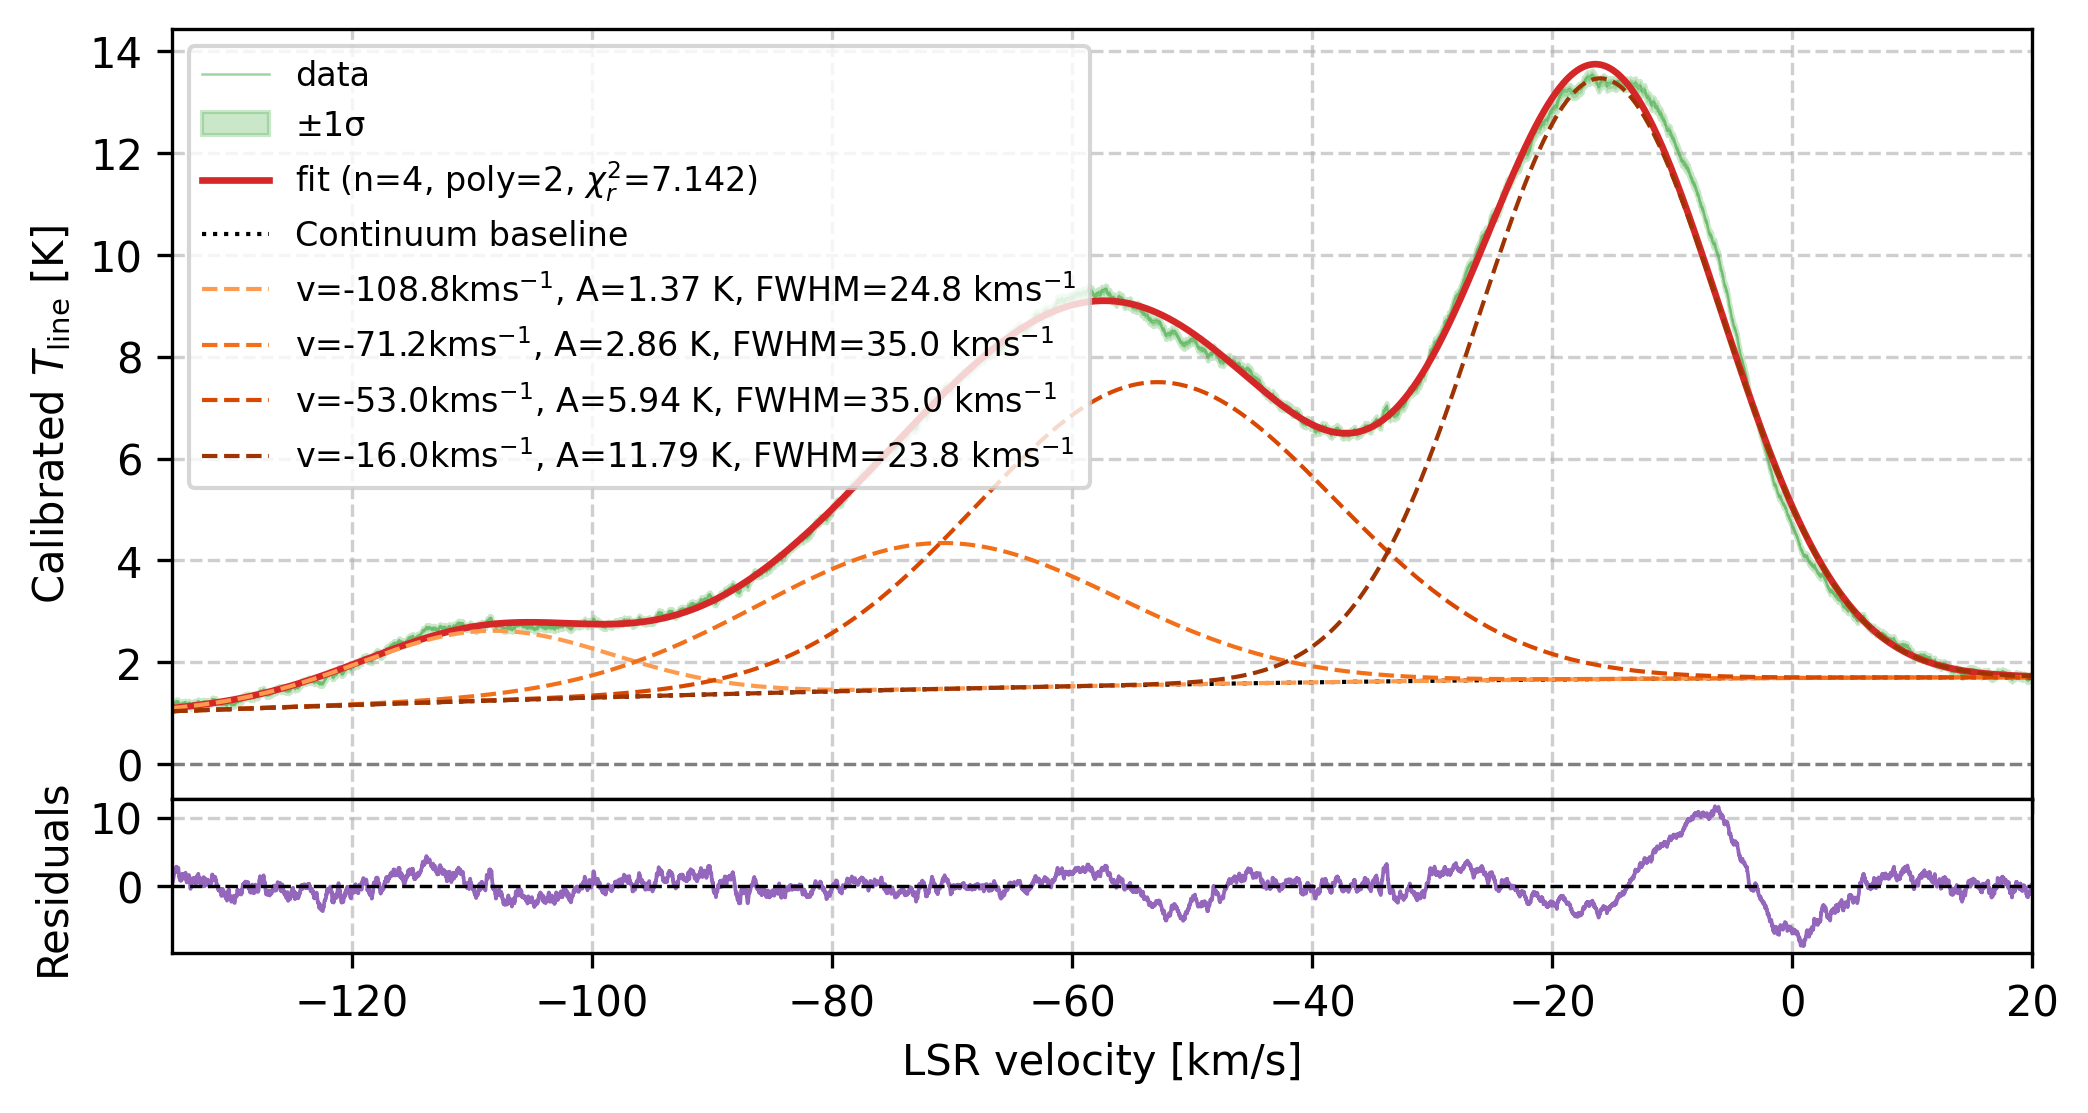

HI profile at (l=120°, b=0°):  residual RMS=2.67


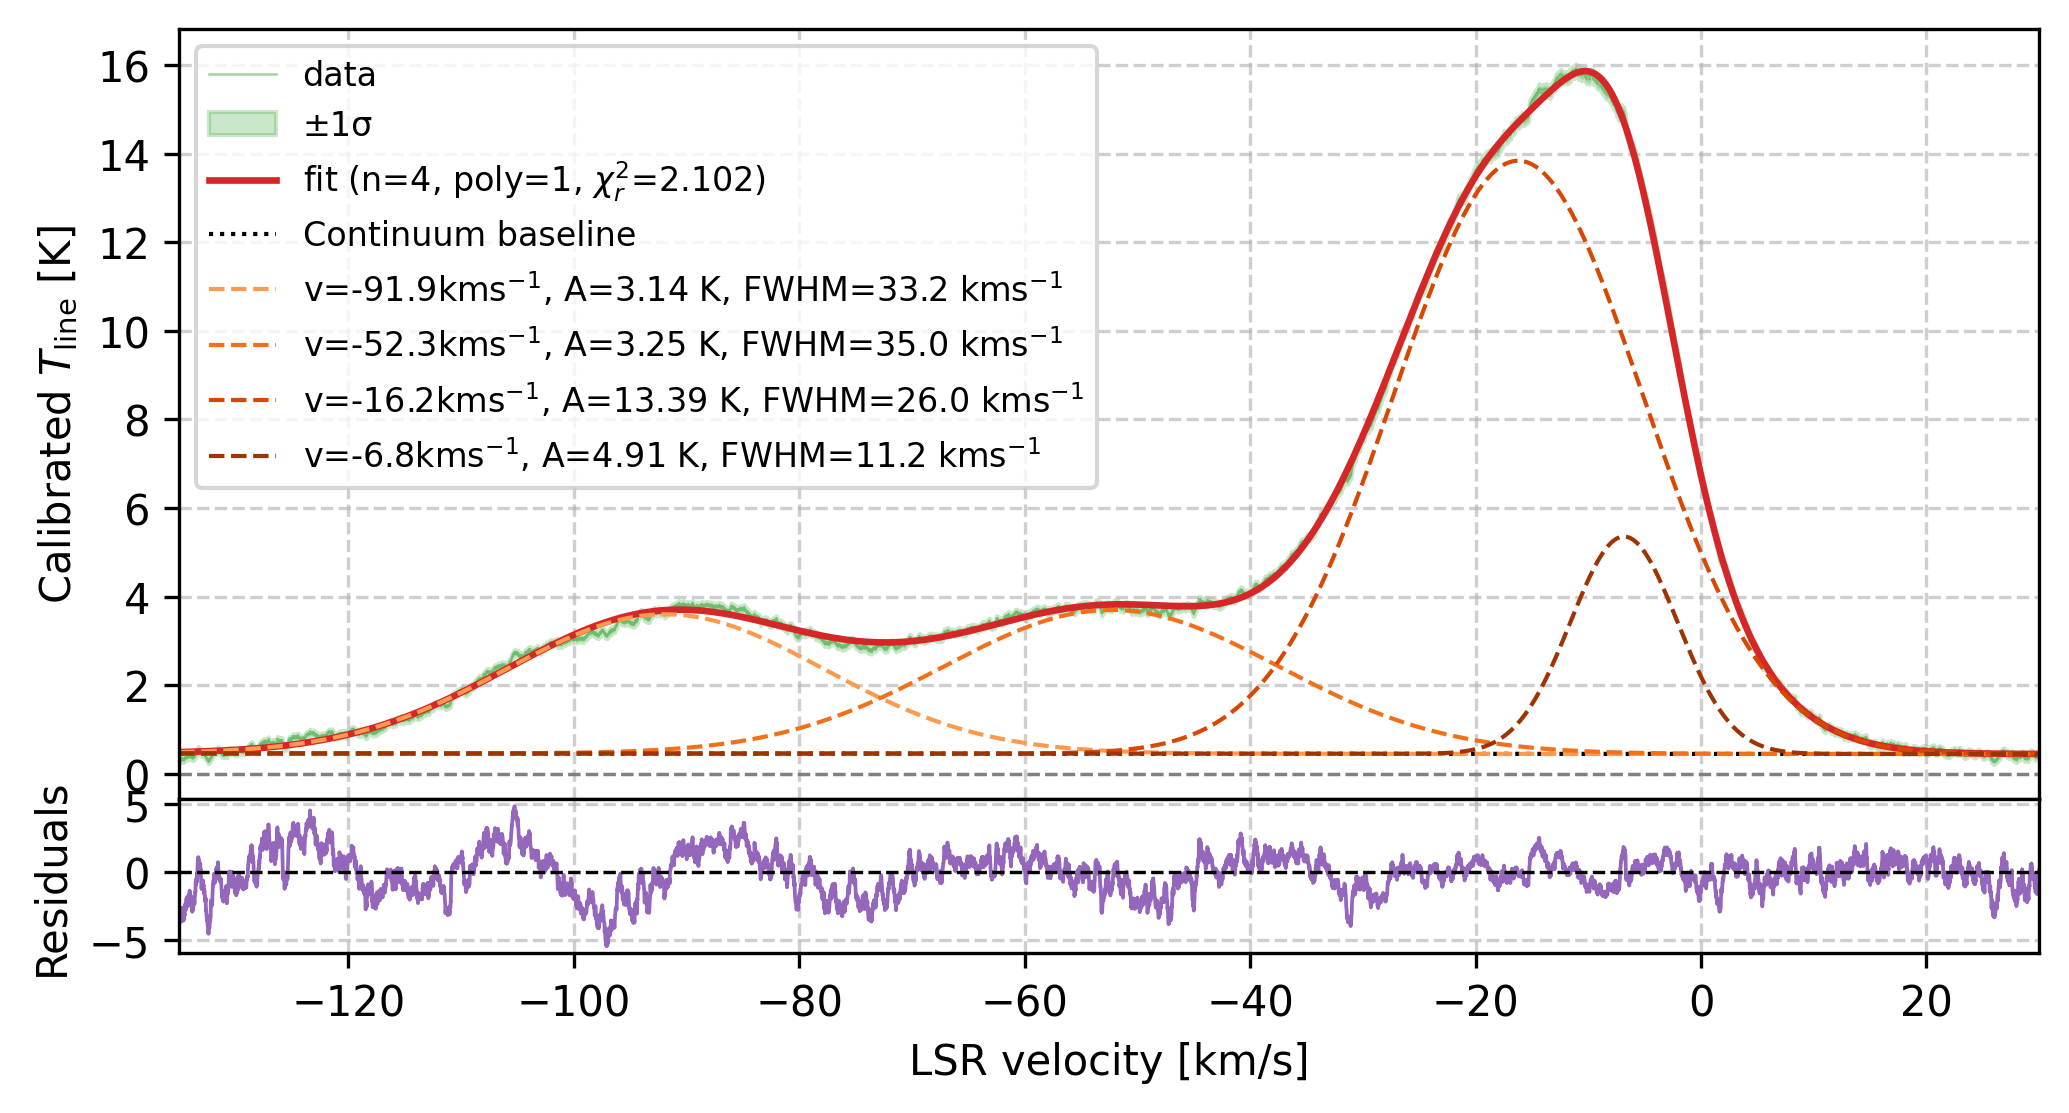

Cygnus-X:  residual RMS=1.45
Calibrated hardware fit summary:


,dataset,profile,n_gauss,poly_order,chi2_red,centroid,sigma_centroid,fwhm_eff,sigma_fwhm_eff,area,sigma_area,residual_rms
0,Cygnus-X,R,4,1,2.101535,-34.712191,0.062507,74.853316,0.115385,660.384105,1.126699,1.448018
1,"HI profile at (l=120°, b=0°)",R,4,2,7.142080,-42.309276,4.880008,70.129244,4.721495,662.650523,124.894841,2.666548


In [61]:
cal_label = ''
display_names = {
    'standard': 'HI profile at (l=120°, b=0°)',
    'cygnus-x': 'Cygnus-X',
}
summary_rows = []

for ds_name in ['standard', 'cygnus-x']:
    ds_label = display_names[ds_name]
    fit_b = temp_fits[(ds_name, 'R')]

    m_b = fit_summary_metrics(fit_b)
    u_b = fit_metric_uncertainty_mc(fit_b, n_draw=250, seed=29)

    vel_min, vel_max = FIT_WINDOWS_KMS[ds_name]
    vgrid = np.linspace(vel_min, vel_max, 2000)

    profile_b = temp_profiles[ds_name]['Tline_R_fit']
    sigma_b = temp_profiles[ds_name]['sTline_R_fit']
    vel_b = temp_profiles[ds_name]['v0']
    finite_b = np.isfinite(vel_b) & np.isfinite(profile_b) & (vel_b >= vel_min) & (vel_b <= vel_max)

    fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True,
                             gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.0})
    axis_cal, axis_cal_resid = axes

    axis_cal.plot(vel_b[finite_b], profile_b[finite_b], lw=0.6, alpha=0.45, color='C2', label=f'{cal_label}data')
    axis_cal.fill_between(vel_b[finite_b], profile_b[finite_b] - sigma_b[finite_b],
                          profile_b[finite_b] + sigma_b[finite_b], color='C2', alpha=0.25, label=f'{cal_label}±1σ')
    model_b = fit_b.model(vgrid)
    p_b = fit_b.popt
    base_b = _eval_poly(vgrid, p_b[3 * fit_b.n_gauss:3 * fit_b.n_gauss + fit_b.poly_order + 1])
    axis_cal.plot(vgrid, model_b, color='C3', lw=1.6,
                  label=rf'{cal_label}fit (n={fit_b.n_gauss}, poly={fit_b.poly_order}, $\chi^2_r$={fit_b.chi2_red:.3f})')
    axis_cal.plot(vgrid, base_b, color='k', lw=1.0, ls=':', label='Continuum baseline')
    comp_colors_b = plt.cm.Oranges(np.linspace(0.45, 0.9, fit_b.n_gauss))
    for k in range(fit_b.n_gauss):
        gk = p_b[3 * k] * np.exp(-0.5 * ((vgrid - p_b[3 * k + 1]) / p_b[3 * k + 2]) ** 2)
        fwhm_kms = 2.355 * p_b[3 * k + 2]
        comp_label = f'v={p_b[3 * k + 1]:.1f}' + r'kms$^{-1}$' + f', A={p_b[3 * k]:.2f} K, FWHM={fwhm_kms:.1f} ' + r'kms$^{-1}$'
        axis_cal.plot(vgrid, base_b + gk, lw=1.0, ls='--', color=comp_colors_b[k], label=comp_label)
    axis_cal.axhline(0, color='gray', lw=0.8, ls='--')
    axis_cal.set_ylabel(r'Calibrated $T_{\mathrm{line}}$ [K]')
    axis_cal.legend(fontsize=8)
    axis_cal.tick_params(axis='x', which='both', labelbottom=False)
    axis_cal.grid(True, alpha=0.6, ls='--')

    resid_b = (profile_b[finite_b] - fit_b.model(vel_b[finite_b])) / np.maximum(sigma_b[finite_b], 1e-9)
    axis_cal_resid.plot(vel_b[finite_b], resid_b, color='C4', lw=0.9)
    axis_cal_resid.axhline(0, color='black', lw=0.8, ls='--')
    axis_cal_resid.set_ylabel('Residuals')
    axis_cal_resid.set_xlabel('LSR velocity [km/s]')
    axis_cal_resid.set_xlim(vel_min, vel_max)
    axis_cal_resid.grid(True, alpha=0.6, ls='--')

    fig.subplots_adjust(hspace=0.0)
    _nb_dir = Path('labs/02') if Path('labs/02').exists() else Path('.')
    plt.savefig(_nb_dir / 'report' / 'figures' / f'{ds_name}_fits.pdf', bbox_inches='tight')
    plt.show()

    resid_rms = np.nanstd(resid_b)
    print(f"{ds_label}: {cal_label} residual RMS={resid_rms:.2f}")

    summary_rows.append(dict(
        dataset=ds_label,
        profile='R',
        n_gauss=fit_b.n_gauss,
        poly_order=fit_b.poly_order,
        chi2_red=fit_b.chi2_red,
        centroid=m_b['centroid'],
        sigma_centroid=u_b['sigma_centroid'],
        fwhm_eff=m_b['fwhm_eff'],
        sigma_fwhm_eff=u_b['sigma_fwhm_eff'],
        area=m_b['area'],
        sigma_area=u_b['sigma_area'],
        residual_rms=resid_rms,
    ))

summary_df = pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True)

print('Calibrated hardware fit summary:')
display(summary_df)


## Step 15 - Final Reporting Blocks and Calibration-Link Check

In [36]:

# Detailed per-fit component tables
for label, fit_dict in [('Path A (ratio-domain)', ratio_fits), ('Path B (calibrated)', temp_fits)]:
    print(f'\n===== {label} component parameters =====')
    rows = []
    for (ds_name, tag), fit in fit_dict.items():
        for k in range(fit.n_gauss):
            A = fit.popt[3*k]
            sA = fit.perr[3*k]
            mu = fit.popt[3*k+1]
            smu = fit.perr[3*k+1]
            sig_k = fit.popt[3*k+2]
            ssig = fit.perr[3*k+2]
            rows.append(dict(
                dataset=ds_name,
                profile=tag,
                comp=k+1,
                A=A,
                sigma_A=sA,
                v0_kms=mu,
                sigma_v0_kms=smu,
                fwhm_kms=2.355*sig_k,
                sigma_fwhm_kms=2.355*ssig,
                chi2_red=fit.chi2_red,
            ))
    display(pd.DataFrame(rows).sort_values(['dataset', 'profile', 'comp']).reset_index(drop=True))

# Link to efficiency estimate produced by calibration workflow
eta_csv = next((p for p in ETA_PATHS if p.exists()), None)
if eta_csv is not None:
    with eta_csv.open() as f:
        eta_row = next(csv.DictReader(f))
    print(f'\nEfficiency estimate file: {eta_csv}')
    print(f"  eta_eff           : {float(eta_row['eta_eff']):.6f}")
    print(f"  eta_eff_sigma     : {float(eta_row['eta_eff_sigma']):.6f}")
    print(f"  eta_eff_ci95      : [{float(eta_row['eta_eff_ci95_lo']):.6f}, {float(eta_row['eta_eff_ci95_hi']):.6f}]")
else:
    print('\nEfficiency estimate CSV not found in expected locations.')

print('\nRequirement-compliance checks:')
print('  [x] dual-path outputs produced (ratio + calibrated/hardware-aware)')
print(f'  [x] {CAL_PATH.name} consumed')
print('  [x] equipment_calibration_results_v2.npz consumed')
print('  [x] LSR correction applied')
print('  [x] mean/median comparison completed and smoothing policy enforced (<1 km/s)')
print('  [x] FIR edge/aliasing placement check completed')
print('  [x] signal-chain linearity/headroom sanity check completed')
print('  [x] baseline + Gaussian model selection with reduced-chi-square diagnostics')
print('  [x] cross-path agreement metrics reported')
print('  [x] pointing-aware LSR correction (Az/Alt->ICRS with zenith fallback)')
print('  [x] exact inverse-ratio temperature transform applied')
print('  [x] combined_eval_mask + sigma_hw_fraction dependencies consumed')



===== Path A (ratio-domain) component parameters =====


,dataset,profile,comp,A,sigma_A,v0_kms,sigma_v0_kms,fwhm_kms,sigma_fwhm_kms,chi2_red
0,cygnus-x,R,1,0.075434,0.000624,-92.228933,0.069746,30.915033,0.196838,2.349293
1,cygnus-x,R,2,0.073518,0.000815,-52.481147,0.057982,35.000000,0.280837,2.349293
2,cygnus-x,R,3,0.338446,0.000922,-16.481751,0.030987,25.288634,0.050734,2.349293
3,cygnus-x,R,4,0.135557,0.000909,-6.777579,0.015020,11.567555,0.053750,2.349293
4,cygnus-x,Rinv,1,0.080627,0.000729,-92.276571,0.085584,31.981553,0.230291,2.755183
5,cygnus-x,Rinv,2,0.077512,0.000911,-52.833875,0.069078,35.000000,0.339448,2.755183
6,cygnus-x,Rinv,3,0.334207,0.000994,-16.577019,0.033985,25.430837,0.056368,2.755183
7,cygnus-x,Rinv,4,0.128932,0.000940,-6.862687,0.016277,11.432439,0.055891,2.755183
8,standard,R,1,0.053956,0.003566,-108.543482,0.431277,26.672607,0.912544,11.888884
9,standard,R,2,0.104745,0.095811,-72.034795,9.862013,35.000000,6.704602,11.888884



===== Path B (calibrated) component parameters =====


,dataset,profile,comp,A,sigma_A,v0_kms,sigma_v0_kms,fwhm_kms,sigma_fwhm_kms,chi2_red
0,cygnus-x,R,1,3.144322,0.008886,-91.874046,0.076446,33.169133,0.160674,2.101535
1,cygnus-x,R,2,3.245198,0.005130,-52.306975,0.056828,35.000000,0.272527,2.101535
2,cygnus-x,R,3,13.388084,0.017546,-16.217453,0.026378,25.970071,0.031441,2.101535
3,cygnus-x,R,4,4.905260,0.025436,-6.834313,0.017386,11.186154,0.049825,2.101535
4,cygnus-x,Rinv,1,2.620652,0.036748,-70.806113,0.159532,23.482873,0.256557,9.342334
5,cygnus-x,Rinv,2,6.329724,0.113330,-39.930129,0.130960,35.000000,0.540348,9.342334
6,cygnus-x,Rinv,3,9.433541,1.591555,5.922464,0.374233,20.346196,0.811405,9.342334
7,cygnus-x,Rinv,4,21.148613,0.579741,29.474770,0.205320,35.000000,3.971504,9.342334
8,standard,R,1,1.371089,0.064630,-108.794863,0.264508,24.761531,0.637843,7.142080
9,standard,R,2,2.864674,2.623114,-71.169875,9.184297,35.000000,5.453594,7.142080



Efficiency estimate file: report/eta_eff_estimate.csv
  eta_eff           : 0.000671
  eta_eff_sigma     : 0.349852
  eta_eff_ci95      : [-0.685038, 0.686381]

Requirement-compliance checks:
  [x] dual-path outputs produced (ratio + calibrated/hardware-aware)
  [x] calibration_results_v2.npz consumed
  [x] equipment_calibration_results_v2.npz consumed
  [x] LSR correction applied
  [x] mean/median comparison completed and smoothing policy enforced (<1 km/s)
  [x] FIR edge/aliasing placement check completed
  [x] signal-chain linearity/headroom sanity check completed
  [x] baseline + Gaussian model selection with reduced-chi-square diagnostics
  [x] cross-path agreement metrics reported
  [x] pointing-aware LSR correction (Az/Alt->ICRS with zenith fallback)
  [x] exact inverse-ratio temperature transform applied
  [x] combined_eval_mask + sigma_hw_fraction dependencies consumed
